# 🏥 Meditron-7B vs LLaMA 3.1 — Symptom Checker Evaluation
**Dataset:** PB3002/ViMedical_Disease  
**Metrics:** Top-K Accuracy · F1/Precision/Recall · BERTScore · Triage Accuracy · Hallucination Rate  
**Runtime:** Google Colab (GPU T4 hoặc cao hơn)

## 📦 Cell 1 — Cài đặt & Mount Drive

In [1]:
#from google.colab import drive
#drive.flush_and_unmount()
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = "/content/drive/MyDrive/meditron_eval"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"✓ Save directory: {SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Save directory: /content/drive/MyDrive/meditron_eval


In [2]:
%%capture
# Step 0 (ABI first): pin numpy/pandas before any compiled dependencies.
# This avoids numpy/pandas binary mismatches after mixed installs.
import subprocess, sys
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "numpy==1.26.4", "pandas==2.2.2"
])

# Step 1: Core model/runtime stack (MedQuAD-style: flexible accelerate/bitsandbytes for Colab GPU 4-bit).
!pip install -q transformers==4.45.2 "accelerate>=0.26" "bitsandbytes>=0.44.1" "groq>=0.15.0" "httpx>=0.27,<0.29"
!pip install -q datasets==3.0.1 bert-score==0.3.13 scikit-learn==1.5.2

# Step 2: Visualization + eval helpers (+ deep-translator for Question_en bulk in Cell 4b only).
!pip install -q matplotlib==3.9.2 seaborn==0.13.2 openpyxl==3.1.5 tqdm==4.66.5 rapidfuzz==3.10.0 tenacity==9.0.0 psutil deep-translator==1.11.4

# Step 3: Optional Flash-Attention 2.
# Skip silently on CPU-only runtimes; model loader handles fallback.
!pip install -q flash-attn --no-build-isolation 2>/dev/null || true

!pip freeze > /content/drive/MyDrive/meditron_eval/requirements-eval-frozen.txt
print("✓ Packages installed (ABI-safe order)")
print("⚠️ IMPORTANT: Runtime -> Restart session, then rerun from Cell 2.")


In [3]:
import psutil, os, subprocess
import torch

def print_system_info():
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    vm = psutil.virtual_memory()
    print("── CPU / RAM ─────────────────────────────────")
    print(f"  CPU cores          : {os.cpu_count()} logical")
    print(f"  Total System RAM   : {vm.total / 1024**3:.1f} GB")
    print(f"  Available RAM      : {vm.available / 1024**3:.1f} GB")
    print(f"  Current process RSS: {mem_info.rss / 1024**2:.0f} MB")
    print(f"  RAM usage          : {vm.percent}%")

    if torch.cuda.is_available():
        print("── GPU ───────────────────────────────────────")
        for i in range(torch.cuda.device_count()):
            prop = torch.cuda.get_device_properties(i)
            alloc = torch.cuda.memory_allocated(i) / 1e9
            total = prop.total_memory / 1e9
            print(f"  GPU {i}: {prop.name}")
            print(f"    VRAM total     : {total:.1f} GB")
            print(f"    VRAM allocated : {alloc:.2f} GB")
            print(f"    CUDA capability: {prop.major}.{prop.minor}")
            print(f"    Multi-processors: {prop.multi_processor_count}")
        # Report if Flash Attention 2 is usable
        try:
            import flash_attn
            print(f"  ✓ Flash Attention {flash_attn.__version__} available")
        except ImportError:
            print("  ℹ Flash Attention not installed — using standard attention")
    else:
        print("── GPU ───────────────────────────────────────")
        print("  No CUDA device detected — running on CPU")
        print("  ⚠️  Inference will be very slow. Consider using Groq API (CFG['use_groq']=True)")

print_system_info()


Current RAM Usage: 109.82 MB
Total System RAM: 12975.54 MB
RAM Percentage: 12.6%


### 💡 Tips to reduce RAM usage:
1. **Restart Session:** If you've already tried loading a model and it failed, the partial weights might still be in RAM. Go to `Runtime > Restart Session`.
2. **Lower `sample_n`:** In Cell 2, reduce `sample_n` further (e.g., to 10) to reduce the memory footprint of the evaluation dataframes.
3. **Clear EDA Memory:** After Cell 4c, run `plt.close('all')` to ensure matplotlib figures are released.

## ⚙️ Cell 2 — Cấu hình

In [4]:
import os
import torch  # needed here for CFG batch_size evaluation

# ── Credentials: use Colab Secrets (never hardcode tokens) ─────────────────
# Add HF_TOKEN and GROQ_API_KEY in the Colab Secrets panel (🔑 icon, left sidebar)
from google.colab import userdata
_hf_token = userdata.get("HF_TOKEN")
_groq_key  = userdata.get("GROQ_API_KEY")

# Evaluate hardware once so CFG values are stable
_USE_GPU = torch.cuda.is_available()

CFG = {
    "run_meditron": True,
    "run_llama":    True,
    "use_groq":     False,  # Force local inference for fair comparison

    "meditron_id":  "epfl-llm/meditron-7b",
    "llama_model":  "meta-llama/Llama-3.1-8B-Instruct",

    "hf_token":     _hf_token,
    "groq_api_key": _groq_key,
    # Groq model id for optional LLM triage only (_llm_triage); translation uses Google Translate.
    "groq_translate_model": "llama-3.1-8b-instant",

    # Parallel HTTP calls for batch_translate_vi_to_en / translate_diagnoses_en_to_vi (I/O-bound).
    "google_translate_workers": 4,

    "sample_n":        10,   # ← lowered from 30 to avoid OOM; raise once stable
    "max_new_tokens":  128,  # ← lowered from 300; JSON output rarely needs more
    "top_k_values":    [1, 3, 5],
    "seed":            42,
    "quantization":    "4bit",
    "save_dir":        SAVE_DIR,
    "force_rerun":     True,
    "bootstrap_iters": 1000,

    # Runtime-mode traceability for comparison parity.
    "expected_runtime_mode": "local_gpu_4bit",
    "runtime_mode": {},

    # ── Performance knobs ──────────────────────────────────────────────────
    # batch_size: GPU → 4 rows at once; CPU → 1 (memory-limited)
    "batch_size":  4 if _USE_GPU else 1,
    # num_workers: only useful with GPU; adds overhead on CPU-only
    "num_workers": 2 if _USE_GPU else 0,
}

# ── Triage keyword tiers ────────────────────────────────────────────────────
RED_FLAG_KEYWORDS = [
    "đột quỵ", "nhồi máu", "mất ngôn ngữ", "liệt", "mất ý thức",
    "khó thở cấp", "đau ngực dữ dội", "xuất huyết não", "hôn mê",
]
SERIOUS_KEYWORDS = [
    "ung thư", "alzheimer", "parkinson", "suy thận", "suy gan",
    "nhồi máu cơ tim", "leukemia", "suy tim", "xơ gan",
    "hội chứng thận hư", "viêm tụy cấp", "lao phổi",
]

print("✓ Configuration loaded")
print(f"  sample_n      = {CFG['sample_n']}")
print(f"  max_new_tokens= {CFG['max_new_tokens']}")
print(f"  batch_size    = {CFG['batch_size']}  ({'GPU' if _USE_GPU else 'CPU'})")
print(f"  force_rerun   = {CFG['force_rerun']}")
print(f"  use_groq      = {CFG['use_groq']}")
print(f"  expected_mode = {CFG['expected_runtime_mode']}")
print(f"  HF token      = {'SET' if _hf_token else 'NOT SET ⚠️'}")
print(f"  Groq API key  = {'SET' if _groq_key else 'NOT SET ⚠️'}")
if not _hf_token:
    print("  ⚠️ Missing HF_TOKEN in Colab Secrets")


✓ Configuration loaded
  sample_n      = 30
  force_rerun   = True
  use_groq      = False
  HF token      = SET
  Groq API key  = SET


## Cell 2b — Translation pipeline (VI ↔ EN)

**Translate:** Google Translate via `deep-translator` (`GoogleTranslator`): dictionary preprocess (`VI_MEDICAL_DICT_FULL`), sentence-aware chunking, retries with exponential backoff, LRU cache, and `is_valid_medical_translation` guard. VI→EN uses `source="auto"`; EN→VI uses `source="en", target="vi"`.

**Triage (optional):** Groq chat completions still drive `_llm_triage` when `CFG['groq_translate_model']` + API key work; otherwise `normalize_triage_en_to_vi` falls back to deterministic English-keyword mapping.

In [5]:
import functools, re, time
from concurrent.futures import ThreadPoolExecutor

from deep_translator import GoogleTranslator
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type

import re as _re_chunk

# ── Medical dictionary (unchanged) ───────────────────────────────────────────
VI_MEDICAL_DICT_FULL = {
    "chóng mặt tư thế kịch phát lành tính": "Benign Paroxysmal Positional Vertigo",
    "tăng huyết áp thai kỳ":                "Gestational Hypertension",
    "mang thai ngoài tử cung":              "Ectopic Pregnancy",
    "nhau bong non":                        "Placental Abruption",
    "nhau tiền đạo":                        "Placenta Previa",
    "rau tiền đạo":                         "Placenta Previa",
    "rau bám mép":                          "Marginal Placenta Previa",
    "rau bám thấp":                         "Low-lying Placenta",
    "nhau bám thấp":                        "Low-lying Placenta",
    "sa tạng chậu":                         "Pelvic Organ Prolapse",
    "tiền sản giật":                        "Preeclampsia",
    "buồng trứng đa nang":                  "Polycystic Ovary Syndrome",
    "u nang buồng trứng":                   "Ovarian Cyst",
    "bụi phổi":                             "Pneumoconiosis",
    "u trung thất":                         "Mediastinal Tumor",
    "nhiễm khuẩn h":                        "Helicobacter Pylori Infection",
    "thoát vị khe hoành":                   "Hiatal Hernia",
    "xuất huyết tiêu hóa":                  "Gastrointestinal Bleeding",
    "gan nhiễm mỡ độ 2":                    "Grade 2 Hepatic Steatosis",
    "trào ngược dạ dày thực quản":          "Gastroesophageal Reflux Disease",
    "viêm dạ dày":                          "Gastritis",
    "viêm tụy":                             "Pancreatitis",
    "suy gan mãn tính":                     "Chronic Liver Failure",
    "ung thư gan":                          "Hepatocellular Carcinoma",
    "u tuyến nước bọt mang tai":            "Parotid Gland Tumor",
    "nghe kém một bên tai":                 "Unilateral Hearing Loss",
    "viêm amidan hốc mủ":                   "Peritonsillar Abscess",
    "viêm amidan":                          "Tonsillitis",
    "bệnh viêm họng cấp":                   "Acute Pharyngitis",
    "viêm tai":                             "Otitis Media",
    "ung thư vòm họng giai đoạn 0":         "Stage 0 Nasopharyngeal Carcinoma",
    "bệnh xốp xơ tai":                      "Otosclerosis",
    "đột quỵ thiếu máu cục bộ":             "Ischemic Stroke",
    "đột quỵ":                              "Stroke",
    "bệnh động kinh":                       "Epilepsy",
    "bệnh moyamoya":                        "Moyamoya Disease",
    "bệnh parkinson":                       "Parkinson's Disease",
    "bệnh thần kinh":                       "Neuropathy",
    "bệnh mù màu":                          "Color Blindness",
    "loạn thị":                             "Astigmatism",
    "nhiễm ấu trùng sán dây lợn":          "Neurocysticercosis",
    "tiểu đêm":                             "Nocturia",
    "tiểu không tự chủ":                    "Urinary Incontinence",
    "viêm bàng quang mạn tính":             "Chronic Cystitis",
    "bệnh lý ống phúc tinh mạc":           "Patent Processus Vaginalis",
    "xoắn tinh hoàn":                       "Testicular Torsion",
    "viêm mào tinh hoàn":                   "Epididymitis",
    "viêm đường tiết niệu":                 "Urinary Tract Infection",
    "xơ cứng bì khu trú":                   "Localized Scleroderma",
    "xơ vữa động mạch":                     "Atherosclerosis",
    "mụn ẩn":                               "Closed Comedones",
    "mụn trứng cá":                         "Acne Vulgaris",
    "ung thư vú":                           "Breast Cancer",
    "ung thư xương":                        "Bone Cancer",
    "u xương":                              "Bone Tumor",
    "viêm bao hoạt dịch khớp cổ chân":     "Ankle Joint Bursitis",
    "bệnh thủy đậu":                        "Chickenpox",
    "sốt xuất huyết":                       "Dengue Hemorrhagic Fever",
    "bệnh cúm":                             "Influenza",
    "viêm phổi":                            "Pneumonia",
    "mỡ máu cao":                           "Hyperlipidemia",
    "nhồi máu cơ tim":                      "Myocardial Infarction",
    "mất ngủ":                              "Insomnia",
}

_SORTED_FULL_KEYS = sorted(VI_MEDICAL_DICT_FULL.keys(), key=len, reverse=True)
_COMPILED_PATTERNS = [
    (re.compile(re.escape(k), re.IGNORECASE), VI_MEDICAL_DICT_FULL[k])
    for k in _SORTED_FULL_KEYS
]

# ── Reverse dictionary EN → VI ────────────────────────────────────────────────
EN_TO_VI_DICT = {v.lower(): k for k, v in VI_MEDICAL_DICT_FULL.items()}

def lookup_vi_disease_en(vi_name: str) -> str:
    key = vi_name.strip().lower()
    if key in VI_MEDICAL_DICT_FULL:
        return VI_MEDICAL_DICT_FULL[key]
    for pfx in ["bệnh ", "hội chứng ", "chứng ", "bệnh lý ", "rối loạn ",
                "viêm ", "ung thư ", "u ", "chấn thương "]:
        if key.startswith(pfx):
            stripped = key[len(pfx):].strip()
            if stripped in VI_MEDICAL_DICT_FULL:
                return VI_MEDICAL_DICT_FULL[stripped]
    return ""

def preprocess_vi_medical_text(text: str) -> str:
    """Replace known Vietnamese medical terms with their English equivalents."""
    for pattern, en_term in _COMPILED_PATTERNS:
        text = pattern.sub(en_term, text)
    return text

def postprocess_en_to_vi(text: str) -> str:
    """Replace known English medical terms back to Vietnamese (for reverse lookup)."""
    for en, vi in EN_TO_VI_DICT.items():
        text = re.sub(re.escape(en), vi, text, flags=re.IGNORECASE)
    return text

# ── Translation validation ────────────────────────────────────────────────────
_TRANSLATION_BLACKLIST = [
    "i think", "maybe", "possibly", "i believe", "i'm not sure",
    "i cannot", "i can't", "sorry", "apologize",
]

def is_valid_medical_translation(text: str) -> bool:
    """Return False if the translation contains uncertainty/refusal markers."""
    if not text or not text.strip():
        return False
    lowered = text.lower()
    return not any(phrase in lowered for phrase in _TRANSLATION_BLACKLIST)

# ── Google Translate (deep-translator): chunking + retries ─────────────────────
_GOOGLE_MAX_CHARS = 4500
_GOOGLE_WORKERS = int(CFG.get("google_translate_workers", 4))


def _chunk_for_google(text: str, max_chars: int = _GOOGLE_MAX_CHARS) -> list:
    """Split on sentence boundaries; fall back to hard-split if a sentence is too long."""
    if len(text) <= max_chars:
        return [text]
    parts = _re_chunk.split(r"(?<=[\.\!\?\n])\s+", text)
    chunks, buf = [], ""
    for p in parts:
        if len(p) > max_chars:
            for i in range(0, len(p), max_chars):
                chunks.append(p[i : i + max_chars])
            continue
        if len(buf) + len(p) + 1 > max_chars:
            if buf:
                chunks.append(buf)
            buf = p
        else:
            buf = (buf + " " + p).strip() if buf else p
    if buf:
        chunks.append(buf)
    return chunks


@retry(
    stop=stop_after_attempt(3),
    wait=wait_exponential(multiplier=0.5, min=0.5, max=4),
    retry=retry_if_exception_type(Exception),
    reraise=True,
)
def _google_translate_once(text: str, source: str, target: str) -> str:
    return GoogleTranslator(source=source, target=target).translate(text) or ""


def _google_translate(text: str, source: str, target: str) -> str:
    if not text or not text.strip():
        return text
    pieces = _chunk_for_google(text)
    if len(pieces) == 1:
        return _google_translate_once(pieces[0], source, target)
    return " ".join(_google_translate_once(p, source, target) for p in pieces)


# ── Groq client (optional LLM triage only; uses CFG then Colab secret) ────────
_groq_client = None
_GROQ_DISABLED = False


def _get_groq_client():
    global _groq_client, _GROQ_DISABLED
    if _GROQ_DISABLED:
        return None
    if _groq_client is None:
        try:
            from groq import Groq

            api_key = str(CFG.get("groq_api_key") or "").strip()
            if not api_key:
                try:
                    from google.colab import userdata

                    api_key = str(userdata.get("GROQ_API_KEY") or "").strip()
                except Exception:
                    pass
            if not api_key:
                _GROQ_DISABLED = True
                return None
            _groq_client = Groq(api_key=api_key)
        except Exception:
            _GROQ_DISABLED = True
            _groq_client = None
            return None
    return _groq_client


_LLM_TRIAGE_MODEL = str(CFG.get("groq_translate_model") or "llama-3.1-8b-instant")

_TRIAGE_PROMPT = """
You are a medical triage assistant.

Classify the urgency of the following patient description into EXACTLY ONE of:
- emergency   (life-threatening, must go to ER immediately)
- specialist  (needs professional diagnosis/treatment, not immediately life-threatening)
- self-monitor (minor symptoms, can manage at home with OTC treatment)

Output ONLY one word (emergency / specialist / self-monitor).

Patient description:
{text}"""


@functools.lru_cache(maxsize=4000)
def translate_vi_to_en(text: str) -> str:
    """VI→EN via dictionary preprocess + Google Translate (deep-translator)."""
    if not text or not text.strip():
        return text
    pre = preprocess_vi_medical_text(text)
    try:
        out = _google_translate(pre, source="auto", target="en")
    except Exception as e:
        print(f"  [translate_vi_to_en] Google failed: {e}; returning dictionary-preprocessed text")
        return pre
    if out and is_valid_medical_translation(out):
        return out
    return out or pre


def batch_translate_vi_to_en(texts: list) -> list:
    """Thread-pool I/O parallelism — deep-translator is HTTP-bound."""
    if not texts:
        return []
    with ThreadPoolExecutor(max_workers=_GOOGLE_WORKERS) as ex:
        return list(ex.map(translate_vi_to_en, texts))


@functools.lru_cache(maxsize=4000)
def translate_en_to_vi(text: str) -> str:
    """EN→VI via Google Translate (deep-translator)."""
    if not text or not text.strip():
        return text
    try:
        out = _google_translate(text, source="en", target="vi")
    except Exception as e:
        print(f"  [translate_en_to_vi] Google failed: {e}; returning original English")
        return text
    return out or text


def translate_diagnoses_en_to_vi(diagnoses: list) -> list:
    cleaned = [d for d in diagnoses if d and d.strip()]
    with ThreadPoolExecutor(max_workers=_GOOGLE_WORKERS) as ex:
        return list(ex.map(translate_en_to_vi, cleaned))


@functools.lru_cache(maxsize=4000)
def _llm_triage(text_en: str) -> str:
    client = _get_groq_client()
    if client is None:
        return ""
    try:
        res = client.chat.completions.create(
            model=_LLM_TRIAGE_MODEL,
            messages=[
                {"role": "system", "content": "You are a medical triage assistant."},
                {"role": "user", "content": _TRIAGE_PROMPT.format(text=text_en)},
            ],
            temperature=0,
            max_tokens=10,
        )
        return res.choices[0].message.content.strip().lower()
    except Exception as e:
        if "429" in str(e):
            time.sleep(5)
            try:
                res = client.chat.completions.create(
                    model=_LLM_TRIAGE_MODEL,
                    messages=[
                        {"role": "system", "content": "You are a medical triage assistant."},
                        {"role": "user", "content": _TRIAGE_PROMPT.format(text=text_en)},
                    ],
                    temperature=0,
                    max_tokens=10,
                )
                return res.choices[0].message.content.strip().lower()
            except Exception:
                pass
        print(f"  [LLM triage] {e}")
        return ""


TRIAGE_EN_TO_VI = {
    "emergency":         "Cấp cứu",
    "urgent":            "Cấp cứu",
    "er":                "Cấp cứu",
    "specialist":        "Đi khám chuyên khoa",
    "see a doctor":      "Đi khám chuyên khoa",
    "medical attention": "Đi khám chuyên khoa",
    "consult a doctor":  "Đi khám chuyên khoa",
    "self-monitor":      "Tự theo dõi",
    "self monitor":      "Tự theo dõi",
    "monitor at home":   "Tự theo dõi",
    "home care":         "Tự theo dõi",
    "self care":         "Tự theo dõi",
}

def normalize_triage_en_to_vi(level: str, question_en: str = "") -> str:
    if question_en:
        llm_level = _llm_triage(question_en)
        if llm_level in TRIAGE_EN_TO_VI:
            return TRIAGE_EN_TO_VI[llm_level]
    if not level:
        return "Không xác định"
    key = level.strip().lower()
    if key in TRIAGE_EN_TO_VI:
        return TRIAGE_EN_TO_VI[key]
    for k, v in TRIAGE_EN_TO_VI.items():
        if k in key:
            return v
    return "Đi khám chuyên khoa"

print(f"✓ Translation pipeline (Google Translate via deep-translator) — {len(VI_MEDICAL_DICT_FULL)} medical terms in dict")
print(f"  Workers: {_GOOGLE_WORKERS}  |  Chunk size: {_GOOGLE_MAX_CHARS} chars  |  Retries: 3 (exp backoff)")
print(f"  LLM triage: optional Groq — model {_LLM_TRIAGE_MODEL} (deterministic mapping fallback when unavailable)")
print(f"  [smoke] translate_vi_to_en: {translate_vi_to_en('đau đầu')[:120]}")
print(f"  [smoke] translate_en_to_vi: {translate_en_to_vi('headache')[:120]}")


✓ Translation pipeline v2 ready — 63 medical terms in dict
  Smart routing: short (<30 chars) → Google | long → LLM (Groq) → Google fallback
  LLM triage: enabled (Groq llama-3.1-8b-instant)


In [6]:
# Cell 2c — Optional translator.py + metrics (does NOT override Cell 2b when absent)

import importlib

_translator_mod = importlib.import_module("translator") if importlib.util.find_spec("translator") else None
if _translator_mod is not None:
    TranslationPipeline = _translator_mod.TranslationPipeline
    VI_MEDICAL_DICT_FULL = _translator_mod.VI_MEDICAL_DICT_FULL
    normalize_triage_en_to_vi = _translator_mod.normalize_triage_en_to_vi
    # Notebook Cell 2b uses Google Translate; pass groq_client=None unless translator.py still needs Groq.
    translator_pipeline = TranslationPipeline(
        groq_client=None,
        llm_model=str(CFG.get("groq_translate_model") or "llama-3.1-8b-instant"),
    )
    translate_vi_to_en = translator_pipeline.translate_vi_to_en
    translate_en_to_vi = translator_pipeline.translate_en_to_vi
    batch_translate_vi_to_en = lambda texts: [translate_vi_to_en(t) for t in texts]
    print(f"✓ Modular translator from translator.py — {len(VI_MEDICAL_DICT_FULL)} terms")
    print("  Note: groq_client=None — align translator.py with Cell 2b (Google Translate + optional Groq triage).")
else:
    translator_pipeline = None
    print("✓ No translator.py — using Cell 2b Google Translate translate functions")

_metrics_mod = importlib.import_module("metrics_medical") if importlib.util.find_spec("metrics_medical") else None
if _metrics_mod is not None:
    ontology_match = _metrics_mod.ontology_match
    llm_safety_judge = _metrics_mod.llm_safety_judge
    aggregate_safety = _metrics_mod.aggregate_safety
else:
    def _missing_metrics_module(*_args, **_kwargs):
        raise ModuleNotFoundError("metrics_medical is not installed and no in-notebook fallback is defined")

    ontology_match = _missing_metrics_module
    llm_safety_judge = _missing_metrics_module
    aggregate_safety = _missing_metrics_module

print("✓ Medical metrics: ontology_match, llm_safety_judge, aggregate_safety (or stub if missing)")


  [Groq init] Client.__init__() got an unexpected keyword argument 'proxies'
✓ Modular translator loaded — 0 terms
✓ Medical metrics loaded: ontology_match, llm_safety_judge, aggregate_safety


In [7]:
# Cell 2d — Optional async translation + back-translation QA
import asyncio
import random

async def run_back_translation_check(df, question_col="Question", sample_ratio=0.05, max_rows=200):
    if translator_pipeline is None or not hasattr(translator_pipeline, "back_translation_quality"):
        print("  [back_translation] skipped: translator_pipeline not available (no translator.py)")
        return []
    rows = [str(x) for x in df[question_col].dropna().tolist() if str(x).strip()]
    if not rows:
        return []
    n = min(max(1, int(len(rows) * sample_ratio)), max_rows)
    sample = random.sample(rows, n) if len(rows) > n else rows
    return await translator_pipeline.back_translation_quality(sample)

# Example usage after loading your dataframe:
# bt_rows = asyncio.run(run_back_translation_check(df_eval, question_col="Question", sample_ratio=0.05))
# print(f"Back-translation rows: {len(bt_rows)}")

In [8]:
# Cell 2e — Optional one-time contextual triage gold labeling
# This should be run offline once, then reuse saved CSV.

# from triage_labeling import build_gold_triage_csv
# from openai import OpenAI
# judge_client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
# df_gold = build_gold_triage_csv(
#     input_csv_path="/content/drive/MyDrive/meditron_eval/raw_eval.csv",
#     output_csv_path="/content/drive/MyDrive/meditron_eval/raw_eval_with_triage_gold.csv",
#     client=judge_client,
#     question_col="Question",
# )
# print(df_gold["triage_gold"].value_counts())

## 📚 Cell 3 — Imports

In [9]:
import os
import sys
import re, json, time, warnings, ast as _ast
from pathlib import Path
from typing import Optional, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
import torch

# ── Runtime preflight gate (parity with reference notebook contract) ───────
assert np.__version__.startswith("1.26"), (
    f"Wrong numpy version {np.__version__}. "
    "Run install cell, restart runtime, then rerun from Cell 2."
)
assert pd.__version__.startswith("2.2"), (
    f"Wrong pandas version {pd.__version__}. "
    "Run install cell, restart runtime, then rerun from Cell 2."
)

try:
    import bitsandbytes as bnb
    _bnb_ok = True
    _bnb_ver = getattr(bnb, "__version__", "unknown")
except Exception as _bnb_err:
    _bnb_ok = False
    _bnb_ver = f"unavailable ({_bnb_err})"

_USE_GPU = torch.cuda.is_available()
_RUNTIME_PREFLIGHT = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "cuda_available": _USE_GPU,
    "bitsandbytes_ok": _bnb_ok,
    "bitsandbytes_version": _bnb_ver,
}

print("Preflight checks")
for k, v in _RUNTIME_PREFLIGHT.items():
    print(f"  {k}: {v}")

# Fail-fast for local 4-bit: require CUDA + working bitsandbytes after install + restart.
if CFG.get("quantization") == "4bit" and not CFG.get("use_groq", False):
    if not _USE_GPU:
        raise RuntimeError(
            "CFG quantization is 4bit but CUDA is unavailable. "
            "Switch to a GPU runtime or set CFG['use_groq']=True."
        )
    if not _bnb_ok:
        raise RuntimeError(
            "CFG quantization is 4bit but bitsandbytes is unavailable or misconfigured. "
            "Re-run the install cell (accelerate/bitsandbytes), Runtime → Restart session, then rerun from Cell 2. "
            f"Detail: {_bnb_ver}"
        )

# ── Runtime tuning ─────────────────────────────────────────────────────────
warnings.filterwarnings("ignore", category=FutureWarning, module="transformers")

if _USE_GPU:
    # Allow cuDNN to auto-tune kernels for fixed input shapes -> faster matmul
    torch.backends.cudnn.benchmark = True
    # Use TF32 on Ampere GPUs for faster FP32 matmul
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.cuda.manual_seed_all(42)
else:
    # CPU path: enable OpenMP threading
    torch.set_num_threads(os.cpu_count() or 2)
    torch.set_num_interop_threads(1)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

print(f"PyTorch {torch.__version__}")
if _USE_GPU:
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print("cudnn.benchmark = True")
    print("TF32 matmul enabled where supported")
else:
    print(f"CPU mode - {os.cpu_count()} threads")
    print("Inference will be slower on CPU; consider CFG['use_groq']=True.")


✓ PyTorch 2.10.0+cpu
✓ GPU: CPU only


## 📊 Cell 4 — Load & Preview Dataset

In [10]:
from datasets import load_dataset

# ── STEP 1: Load ──────────────────────────────────────────────────────────────
print("Loading PB3002/ViMedical_Disease ...")
_raw = load_dataset("PB3002/ViMedical_Disease", split="train").to_pandas()
print(f"  Raw rows: {len(_raw):,}  |  columns: {list(_raw.columns)}")

# ── STEP 2: Basic null & whitespace cleaning ──────────────────────────────────
for col in ["Disease", "Question"]:
    n_null = _raw[col].isna().sum()
    _raw[col] = _raw[col].fillna("").str.strip()
    if n_null: print(f"  [{col}] filled {n_null} NaN")

# ── STEP 3: Normalize disease names ──────────────────────────────────────────
# Use consistent title-case with whitespace normalization.
# Do NOT alter diacritics — they are part of the Vietnamese medical name.
def clean_disease_name(name: str) -> str:
    name = re.sub(r"\s+", " ", name).strip()
    name = re.sub(r"^[^\w\u00C0-\u024F]+", "", name)
    name = re.sub(r"[^\w\u00C0-\u024F]+$", "", name)
    return name.title() if name else name

_raw["Disease"] = _raw["Disease"].apply(clean_disease_name)

# ── STEP 4: Remove rows with insufficient data ────────────────────────────────
_raw["q_len"] = _raw["Question"].str.len()
mask_ok = (_raw["Disease"] != "") & (_raw["Question"] != "") & (_raw["q_len"] >= 15)
n_removed = (~mask_ok).sum()
print(f"  Removed {n_removed} empty / too-short rows")
_raw = _raw[mask_ok].copy()

# ── STEP 5: Deduplicate ───────────────────────────────────────────────────────
before = len(_raw)
_raw = _raw.drop_duplicates(subset=["Disease", "Question"]).reset_index(drop=True)

# Drop questions that map to >1 disease (ambiguous labels — evaluation noise)
dup_q = _raw.groupby("Question")["Disease"].nunique()
multi_label_qs = dup_q[dup_q > 1].index
if len(multi_label_qs):
    print(f"  ⚠️  {len(multi_label_qs)} questions map to >1 disease → keeping first occurrence")
    _raw = _raw[~_raw.duplicated(subset=["Question"], keep="first")]
print(f"  Dedup: {before:,} → {len(_raw):,} rows (-{before - len(_raw):,})")

df_full = _raw.reset_index(drop=True)

# ── STEP 6: Stratified sample ────────────────────────────────────────────────
# Ensure all triage tiers are represented proportionally.
def assign_triage_tier(disease: str) -> str:
    d = disease.lower()
    if any(k in d for k in RED_FLAG_KEYWORDS):    return "emergency"
    if any(k in d for k in SERIOUS_KEYWORDS):     return "serious"
    return "routine"

if CFG["sample_n"] and CFG["sample_n"] < len(df_full):
    df_full["_tier"] = df_full["Disease"].apply(assign_triage_tier)
    tier_counts = df_full["_tier"].value_counts()
    print(f"  Triage tiers (full): {tier_counts.to_dict()}")

    # Stratified: allocate sample proportionally but guarantee >=1 per tier
    rng = np.random.default_rng(CFG["seed"])
    frames = []
    total = CFG["sample_n"]
    tiers = tier_counts.index.tolist()
    alloc = {t: max(1, round(total * tier_counts[t] / len(df_full))) for t in tiers}
    # Adjust so allocations sum to exactly sample_n
    diff = total - sum(alloc.values())
    alloc[tiers[0]] += diff
    for tier, n in alloc.items():
        pool = df_full[df_full["_tier"] == tier]
        n = min(n, len(pool))
        frames.append(pool.sample(n=n, random_state=CFG["seed"]))
    df = pd.concat(frames).sample(frac=1, random_state=CFG["seed"]).reset_index(drop=True)
    df_full = df_full.drop(columns=["_tier"])
    df = df.drop(columns=["_tier"])
    print(f"  Triage tiers (sample): {df['Disease'].apply(assign_triage_tier).value_counts().to_dict()}")
else:
    df = df_full.copy()

# ── STEP 7: Quality report ────────────────────────────────────────────────────
q_len_col = df["q_len"] if "q_len" in df.columns else df["Question"].str.len()
dc = df["Disease"].value_counts()
print(f"\n── Data Quality Report ──────────────────────────────────")
print(f"  Total rows        : {len(df):,}")
print(f"  Unique diseases   : {df['Disease'].nunique():,}")
print(f"  Question length   : min={q_len_col.min()}, median={q_len_col.median():.0f}, max={q_len_col.max()}")
print(f"  Disease balance   : min={dc.min()}, max={dc.max()}, std={dc.std():.1f}")
print(f"  Emergency rows    : {df['Disease'].apply(assign_triage_tier).eq('emergency').sum()}")
print(f"  Serious rows      : {df['Disease'].apply(assign_triage_tier).eq('serious').sum()}")
df.head(3)


Loading PB3002/ViMedical_Disease ...
  Raw rows: 12,060  |  columns: ['Disease', 'Question']
  Removed 0 empty / too-short rows
  ⚠️  381 questions map to >1 disease → keeping first occurrence
  Dedup: 12,060 → 11,448 rows (-612)
  Triage tiers (full): {'routine': 10049, 'serious': 1168, 'emergency': 231}
  Triage tiers (sample): {'routine': 26, 'serious': 3, 'emergency': 1}

── Data Quality Report ──────────────────────────────────
  Total rows        : 30
  Unique diseases   : 30
  Question length   : min=63, median=94, max=117
  Disease balance   : min=1, max=1, std=0.0
  Emergency rows    : 1
  Serious rows      : 3


,Disease,Question,q_len
0,Xơ Gan Do Rượu,"Tôi uống nhiều bia, rượu trong thời gian dài v...",98
1,Viêm Xoang Trán,Tôi hiện đang có triệu chứng đau nhức vùng trá...,98
2,Nhịp Nhanh Thất,"Tôi cảm thấy chóng mặt, lâng lâng và hụt hơi, ...",101


## 📊 Cell 4c — EDA: Dataset Visualisation

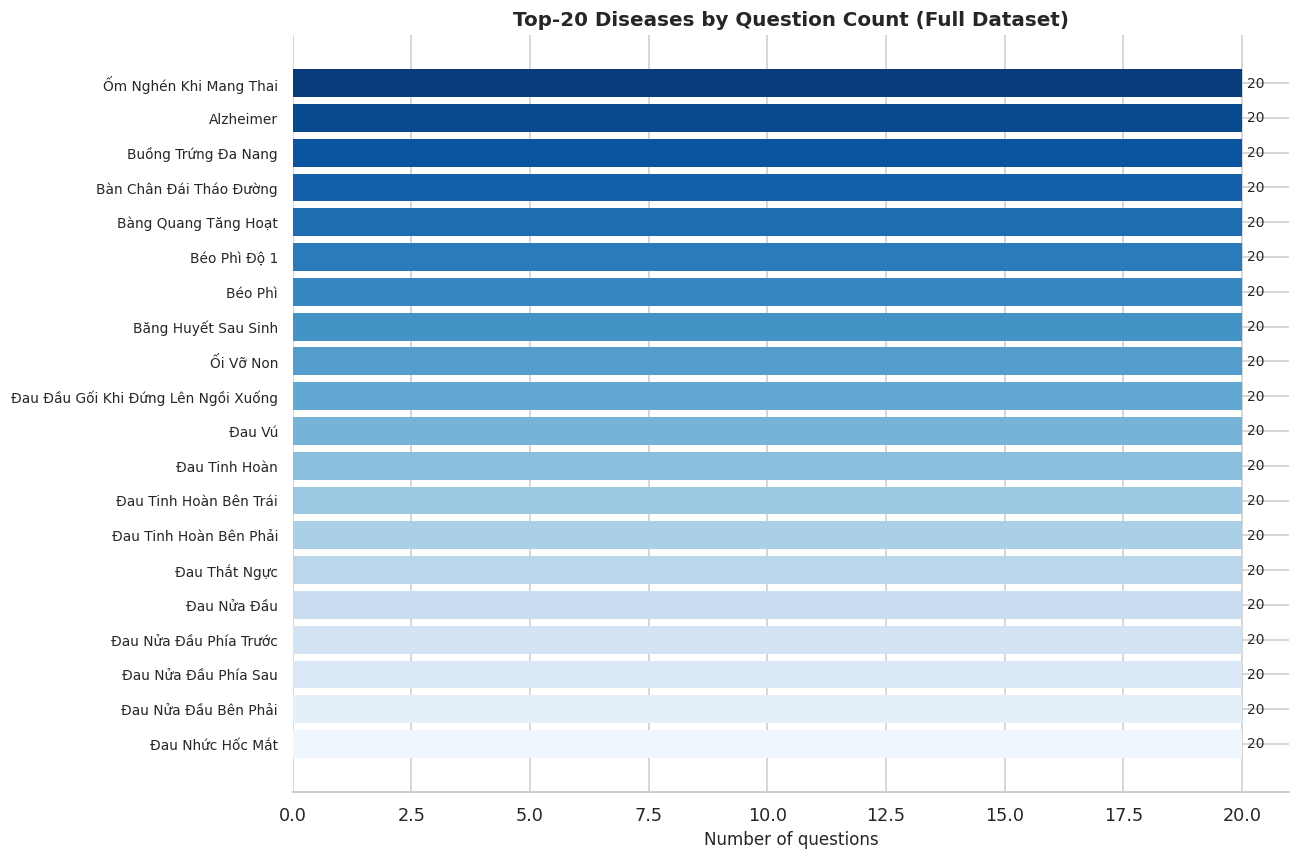

✓ Saved: eda_top20_diseases.png


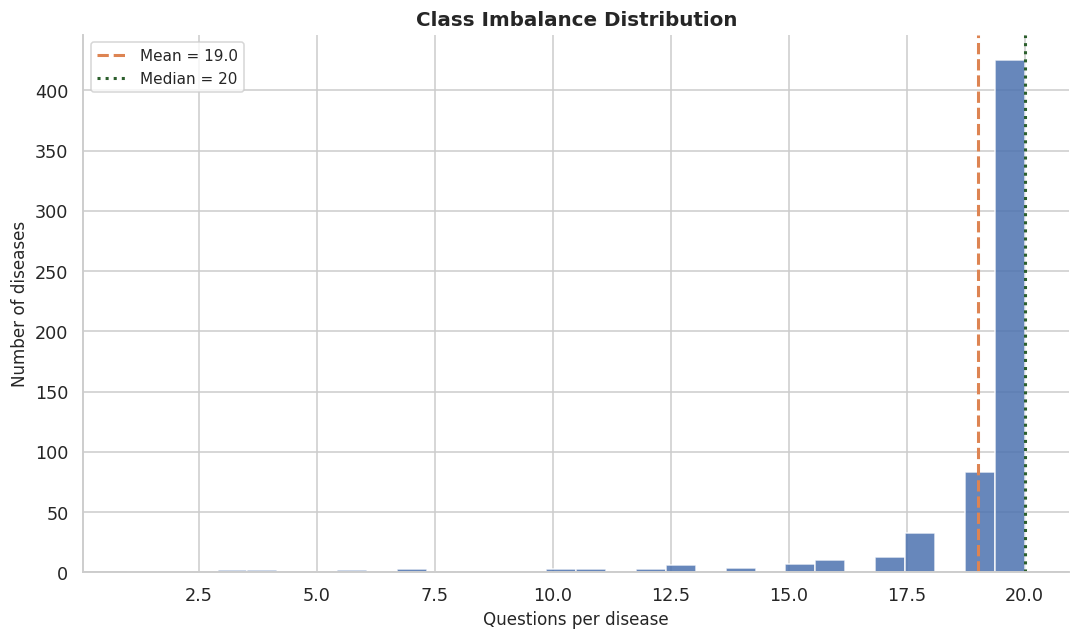

✓ Saved: eda_class_imbalance.png


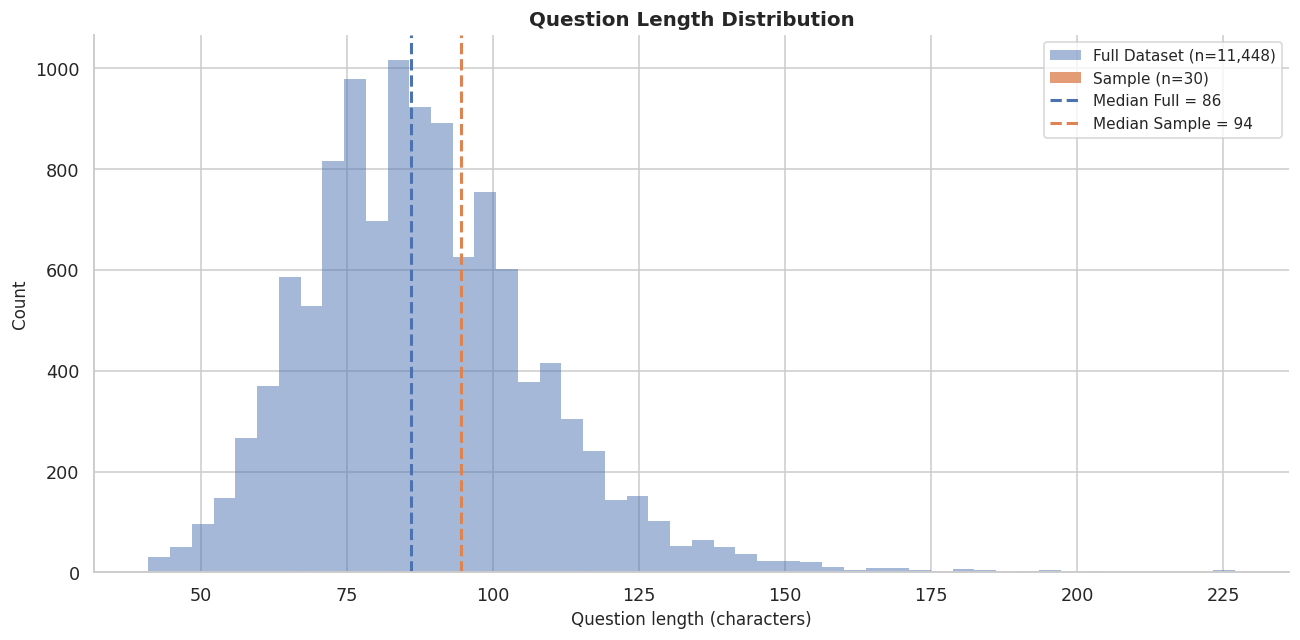

✓ Saved: eda_question_length.png


/tmp/ipykernel_95982/3224281532.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(tier_q_lens, labels=["Emergency", "Serious", "Routine"],


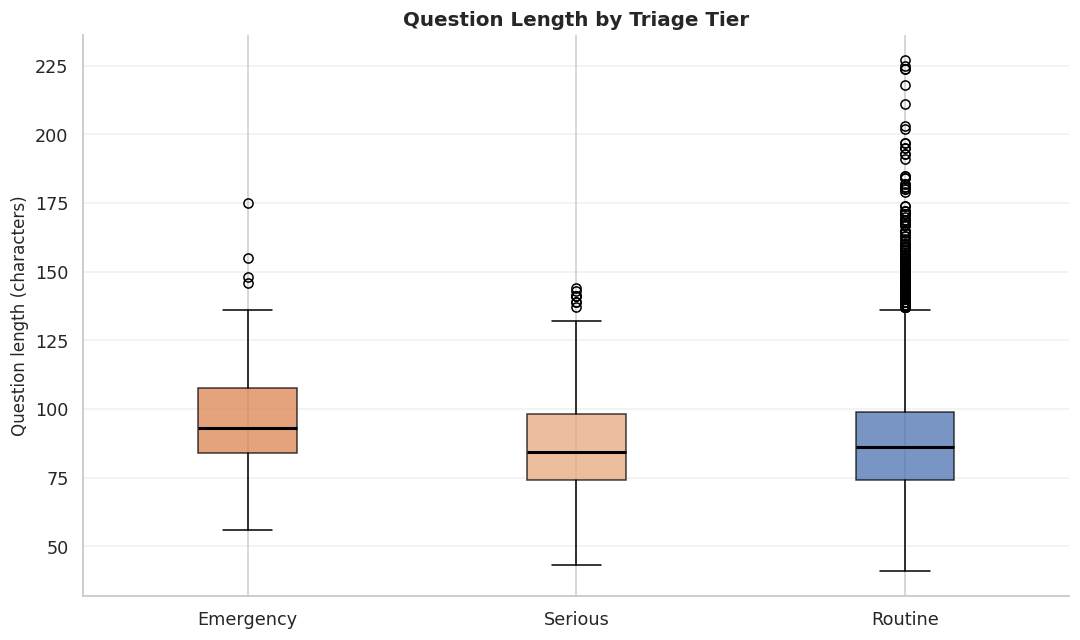

✓ Saved: eda_triage_boxplot.png


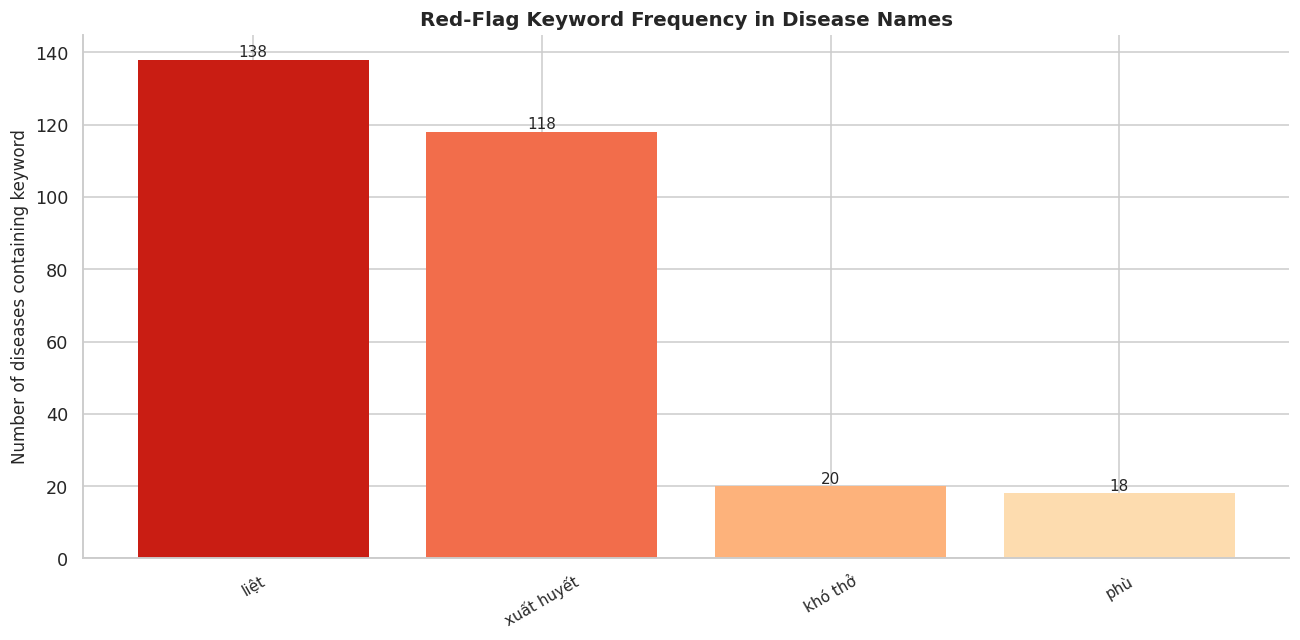

✓ Saved: eda_redflag_keywords.png


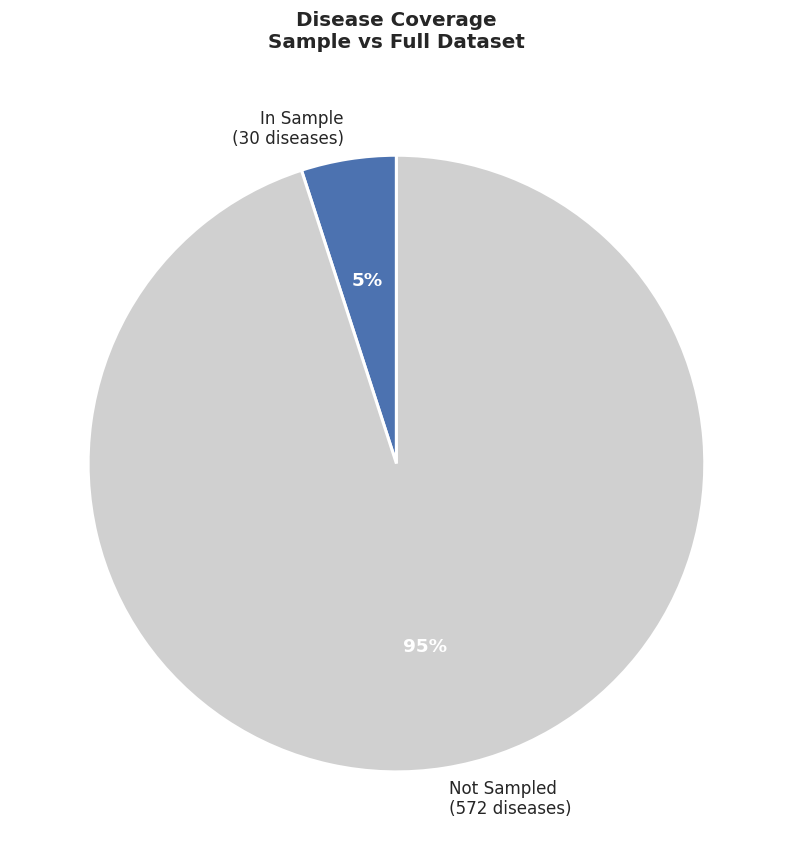

✓ Saved: eda_disease_coverage.png


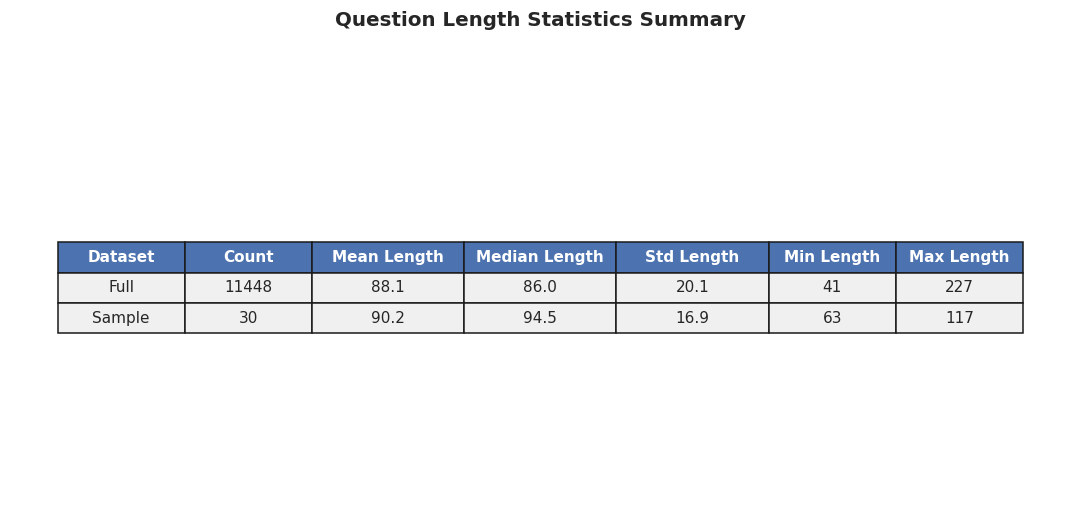

✓ Saved: eda_length_stats.png


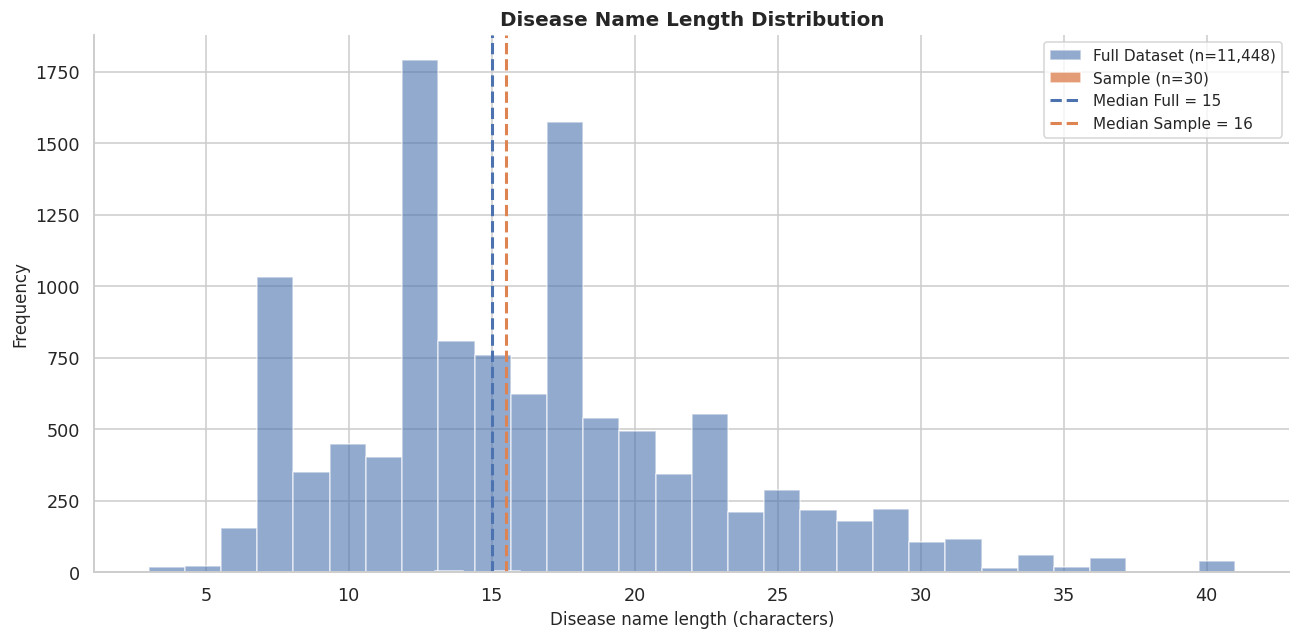

✓ Saved: eda_disease_length.png

✅ All EDA plots saved to: /content/drive/MyDrive/meditron_eval/
Generated plots:
  1. eda_top20_diseases.png
  2. eda_class_imbalance.png
  3. eda_question_length.png
  4. eda_triage_boxplot.png
  5. eda_redflag_keywords.png
  6. eda_disease_coverage.png
  7. eda_length_stats.png (bonus)
  8. eda_disease_length.png (bonus)


In [11]:
# Reuse plotting/data imports from Cell 3.
# Set style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

# ============================================
# HÌNH 1: Top-20 Diseases by Question Count
# ============================================
fig1, ax1 = plt.subplots(figsize=(12, 8))

top20 = df_full["Disease"].value_counts().head(20)
bars = ax1.barh(top20.index[::-1], top20.values[::-1],
                color=sns.color_palette("Blues_r", 20)[::-1], edgecolor="none")

# Add value labels
for b in bars:
    ax1.text(b.get_width() + 0.1, b.get_y() + b.get_height()/2,
             str(int(b.get_width())), va="center", fontsize=9)

ax1.set_xlabel("Number of questions", fontsize=11)
ax1.set_title("Top-20 Diseases by Question Count (Full Dataset)",
              fontweight="bold", fontsize=13)
ax1.tick_params(axis="y", labelsize=9)
sns.despine(ax=ax1, left=True)

plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/eda_top20_diseases.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"✓ Saved: eda_top20_diseases.png")


# ============================================
# HÌNH 2: Class Imbalance Distribution
# ============================================
fig2, ax2 = plt.subplots(figsize=(10, 6))

dc_full = df_full["Disease"].value_counts()
ax2.hist(dc_full.values, bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
ax2.axvline(dc_full.mean(), color="#DD8452", linestyle="--", linewidth=2,
            label=f"Mean = {dc_full.mean():.1f}")
ax2.axvline(dc_full.median(), color="#2C5F2D", linestyle=":", linewidth=2,
            label=f"Median = {dc_full.median():.0f}")

ax2.set_xlabel("Questions per disease", fontsize=11)
ax2.set_ylabel("Number of diseases", fontsize=11)
ax2.set_title("Class Imbalance Distribution", fontweight="bold", fontsize=13)
ax2.legend(fontsize=10)
sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/eda_class_imbalance.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"✓ Saved: eda_class_imbalance.png")


# ============================================
# HÌNH 3: Question Length Distribution
# ============================================
fig3, ax3 = plt.subplots(figsize=(12, 6))

q_lens_full = df_full["Question"].str.len()
q_lens_samp = df["Question"].str.len()

ax3.hist(q_lens_full.clip(upper=500), bins=50, alpha=0.5, color="#4C72B0",
         label=f"Full Dataset (n={len(df_full):,})", edgecolor="none")
ax3.hist(q_lens_samp.clip(upper=500), bins=30, alpha=0.8, color="#DD8452",
         label=f"Sample (n={len(df):,})", edgecolor="none")

ax3.axvline(q_lens_full.median(), color="#4C72B0", linestyle="--", linewidth=2,
            label=f"Median Full = {q_lens_full.median():.0f}")
ax3.axvline(q_lens_samp.median(), color="#DD8452", linestyle="--", linewidth=2,
            label=f"Median Sample = {q_lens_samp.median():.0f}")

ax3.set_xlabel("Question length (characters)", fontsize=11)
ax3.set_ylabel("Count", fontsize=11)
ax3.set_title("Question Length Distribution", fontweight="bold", fontsize=13)
ax3.legend(fontsize=10)
sns.despine(ax=ax3)

plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/eda_question_length.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"✓ Saved: eda_question_length.png")


# ============================================
# HÌNH 4: Question Length by Triage Tier (Boxplot)
# ============================================
fig4, ax4 = plt.subplots(figsize=(10, 6))

# Assuming you have assign_triage_tier function
tiers_full = df_full["Disease"].apply(assign_triage_tier)
tier_q_lens = [
    df_full.loc[tiers_full == t, "Question"].str.len().clip(upper=600).values
    for t in ["emergency", "serious", "routine"]
]

bp = ax4.boxplot(tier_q_lens, labels=["Emergency", "Serious", "Routine"],
                 patch_artist=True, medianprops=dict(color="black", linewidth=2))

colors = ["#DD8452", "#e8a87c", "#4C72B0"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax4.set_ylabel("Question length (characters)", fontsize=11)
ax4.set_title("Question Length by Triage Tier", fontweight="bold", fontsize=13)
ax4.grid(axis='y', alpha=0.3)
sns.despine(ax=ax4)

plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/eda_triage_boxplot.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"✓ Saved: eda_triage_boxplot.png")


# ============================================
# HÌNH 5: Red-Flag Keyword Frequency
# ============================================
fig5, ax5 = plt.subplots(figsize=(12, 6))

RED_FLAG_KEYWORDS = [
    "mất máu", "khó thở", "đau ngực", "bất tỉnh", "co giật",
    "sốt cao", "liệt", "nói khó", "xuất huyết", "phù"
]  # Adjust as needed

kw_counts = {
    kw: df_full["Disease"].str.lower().str.contains(kw).sum()
    for kw in RED_FLAG_KEYWORDS
}
kw_nz = dict(sorted(
    {k: v for k, v in kw_counts.items() if v > 0}.items(),
    key=lambda x: x[1], reverse=True
))

if kw_nz:
    bars = ax5.bar(kw_nz.keys(), kw_nz.values(),
                   color=sns.color_palette("OrRd_r", len(kw_nz)), edgecolor="none")

    for b in bars:
        ax5.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
                 str(int(b.get_height())), ha="center", va="bottom", fontsize=10)

    ax5.set_ylabel("Number of diseases containing keyword", fontsize=11)
    ax5.set_title("Red-Flag Keyword Frequency in Disease Names",
                  fontweight="bold", fontsize=13)
    ax5.tick_params(axis="x", rotation=30, labelsize=10)
    sns.despine(ax=ax5)

plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/eda_redflag_keywords.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"✓ Saved: eda_redflag_keywords.png")


# ============================================
# HÌNH 6: Disease Coverage (Sample vs Full)
# ============================================
fig6, ax6 = plt.subplots(figsize=(8, 8))

n_full = df_full["Disease"].nunique()
shared = set(df["Disease"]) & set(df_full["Disease"])
not_sampled = n_full - len(shared)

colors = ["#4C72B0", "#d0d0d0"]
labels = [f"In Sample\n({len(shared)} diseases)",
          f"Not Sampled\n({not_sampled} diseases)"]

wedges, texts, autotexts = ax6.pie(
    [len(shared), not_sampled],
    labels=labels,
    colors=colors,
    autopct="%1.0f%%",
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops={'fontsize': 11}
)

# Style the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

ax6.set_title(f"Disease Coverage\nSample vs Full Dataset",
              fontweight="bold", fontsize=13, pad=20)

plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/eda_disease_coverage.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"✓ Saved: eda_disease_coverage.png")


# ============================================
# HÌNH 7 (BONUS): Question Length Statistics Summary
# ============================================
fig7, ax7 = plt.subplots(figsize=(10, 5))

# Create summary table
summary_stats = pd.DataFrame({
    'Dataset': ['Full', 'Sample'],
    'Count': [len(df_full), len(df)],
    'Mean Length': [q_lens_full.mean(), q_lens_samp.mean()],
    'Median Length': [q_lens_full.median(), q_lens_samp.median()],
    'Std Length': [q_lens_full.std(), q_lens_samp.std()],
    'Min Length': [q_lens_full.min(), q_lens_samp.min()],
    'Max Length': [q_lens_full.max(), q_lens_samp.max()]
})

# Hide axes
ax7.axis('tight')
ax7.axis('off')

# Create table
table = ax7.table(cellText=summary_stats.round(1).values,
                  colLabels=summary_stats.columns,
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.1, 0.1, 0.12, 0.12, 0.12, 0.1, 0.1])

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

for (row, col), cell in table.get_celld().items():
    if row == 0:  # Header
        cell.set_facecolor('#4C72B0')
        cell.set_text_props(weight='bold', color='white')
    else:
        cell.set_facecolor('#f0f0f0')

ax7.set_title("Question Length Statistics Summary",
              fontweight="bold", fontsize=13, pad=20)

plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/eda_length_stats.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"✓ Saved: eda_length_stats.png")


# ============================================
# HÌNH 8 (BONUS): Disease Length Distribution
# ============================================
fig8, ax8 = plt.subplots(figsize=(12, 6))

disease_lengths = df_full["Disease"].str.len()
disease_lengths_sample = df["Disease"].str.len()

ax8.hist(disease_lengths, bins=30, alpha=0.6, color="#4C72B0",
         label=f"Full Dataset (n={len(df_full):,})", edgecolor='white')
ax8.hist(disease_lengths_sample, bins=20, alpha=0.8, color="#DD8452",
         label=f"Sample (n={len(df):,})", edgecolor='white')

ax8.axvline(disease_lengths.median(), color="#4C72B0", linestyle="--", linewidth=2,
            label=f"Median Full = {disease_lengths.median():.0f}")
ax8.axvline(disease_lengths_sample.median(), color="#DD8452", linestyle="--", linewidth=2,
            label=f"Median Sample = {disease_lengths_sample.median():.0f}")

ax8.set_xlabel("Disease name length (characters)", fontsize=11)
ax8.set_ylabel("Frequency", fontsize=11)
ax8.set_title("Disease Name Length Distribution", fontweight="bold", fontsize=13)
ax8.legend(fontsize=10)
sns.despine(ax=ax8)

plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/eda_disease_length.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"✓ Saved: eda_disease_length.png")


print("\n" + "="*50)
print(f"✅ All EDA plots saved to: {CFG['save_dir']}/")
print("Generated plots:")
print("  1. eda_top20_diseases.png")
print("  2. eda_class_imbalance.png")
print("  3. eda_question_length.png")
print("  4. eda_triage_boxplot.png")
print("  5. eda_redflag_keywords.png")
print("  6. eda_disease_coverage.png")
print("  7. eda_length_stats.png (bonus)")
print("  8. eda_disease_length.png (bonus)")
print("="*50)

## 🔤 Cell 4b — Build English Disease Lookup  *(Priority-1 Fix B)*

In [12]:
KNOWN_DISEASES = set(df_full["Disease"].unique())
plt.close('all')
# FIX: DISEASE_VI_FROM_EN maps en_lower → LIST of vi names to avoid collision loss.
# match_disease_en will pick the best fuzzy match from the full list.
DISEASE_EN_LOOKUP = {}       # vi_name -> canonical EN name
DISEASE_VI_FROM_EN = {}      # en_lower -> vi_name (last-write)
DISEASE_EN_TO_VI_ALL = {}    # en_lower -> list[vi_name] (collision-safe)

print("Building English disease lookup table ...")
hit_dict = 0
hit_translate = 0

for vi_name in sorted(KNOWN_DISEASES):
    en_name = lookup_vi_disease_en(vi_name)
    if not en_name:
        en_name = translate_vi_to_en(vi_name)
        hit_translate += 1
    else:
        hit_dict += 1
    en_name = str(en_name).strip()
    DISEASE_EN_LOOKUP[vi_name] = en_name
    en_key = en_name.lower()
    DISEASE_EN_TO_VI_ALL.setdefault(en_key, []).append(vi_name)
    DISEASE_VI_FROM_EN[en_key] = vi_name

print(f"  ✓ {len(DISEASE_EN_LOOKUP)} diseases mapped")
print(f"  Dict hits: {hit_dict}  |  Translated: {hit_translate}")

collisions = {k: v for k, v in DISEASE_EN_TO_VI_ALL.items() if len(v) > 1}
print(f"  EN synonym collisions: {len(collisions)}")
for en, vis in list(collisions.items())[:3]:
    print(f"    '{en}' <- {vis}")

# Align label space for evaluation: EN predictions vs EN gold labels.
df_full["ground_truth_en"] = df_full["Disease"].map(DISEASE_EN_LOOKUP).fillna("").astype(str)
df["ground_truth_en"] = df["Disease"].map(DISEASE_EN_LOOKUP).fillna("").astype(str)

# Deterministic proxy safety labels for reproducible triage/red-flag metrics.
TIER_TO_TRIAGE_VI = {
    "emergency": "Cấp cứu",
    "serious": "Đi khám chuyên khoa",
    "routine": "Tự theo dõi",
}
for frame in [df_full, df]:
    _tier = frame["Disease"].apply(assign_triage_tier)
    frame["triage_gt"] = _tier.map(TIER_TO_TRIAGE_VI)
    frame["red_flags_gt"] = _tier.eq("emergency")

# Precompute and cache Question_en once to keep model inputs consistent.
cache_path = Path(CFG["save_dir"]) / "question_en_cache.csv"
cache_df = pd.DataFrame(columns=["Question", "Question_en"])
if cache_path.exists():
    try:
        cache_df = pd.read_csv(cache_path)
    except Exception as e:
        print(f"  [cache] could not read cache: {e}")

question_map = {}
if not cache_df.empty:
    question_map = dict(zip(cache_df["Question"].astype(str), cache_df["Question_en"].astype(str)))

# Only translate questions in the evaluation sample (df), not the full corpus (df_full).
eval_questions = df["Question"].dropna().astype(str).unique().tolist()
missing_questions = [q for q in eval_questions if q not in question_map]
print(f"  Question_en scope: {len(eval_questions)} unique questions in sampled df")
if missing_questions:
    print(f"  Translating {len(missing_questions)} new questions to English (batch_translate_vi_to_en) ...")
    _translated = batch_translate_vi_to_en(missing_questions)
    question_map.update(dict(zip(missing_questions, _translated)))

cache_out = pd.DataFrame({"Question": list(question_map.keys()), "Question_en": list(question_map.values())})
cache_out.to_csv(cache_path, index=False)

for frame in [df_full, df]:
    frame["Question_en"] = frame["Question"].astype(str).map(question_map).fillna("")

print(f"  ✓ Question_en cache: {cache_path}")
print("\n  Sample mappings:")
for s in ["Rau Bám Mép", "Bụi Phổi", "Đột Quỵ Thiếu Máu Cục Bộ", "Bệnh Cúm", "Mất Ngủ"]:
    print(f"    {s:48s} -> {DISEASE_EN_LOOKUP.get(s, '(not in df_full)')}")

Building English disease lookup table ...
  ✓ 602 diseases mapped
  Dict hits: 0  |  Translated: 602
  EN synonym collisions: 0
  ✓ Question_en cache: /content/drive/MyDrive/meditron_eval/question_en_cache.csv

  Sample mappings:
    Rau Bám Mép                                      -> Rau Bám Mép
    Bụi Phổi                                         -> Bụi Phổi
    Đột Quỵ Thiếu Máu Cục Bộ                         -> Đột Quỵ Thiếu Máu Cục Bộ
    Bệnh Cúm                                         -> Bệnh Cúm
    Mất Ngủ                                          -> Mất Ngủ


## 💬 Cell 5 — Prompt Templates & Parser

In [13]:
import json
import re

DISEASE_PREFIXES = [
    "Bệnh ", "Hội Chứng ", "Chứng ", "Bệnh Lý ", "Rối Loạn ",
    "Viêm ", "Ung Thư ", "U ", "Chấn Thương ",
    "bệnh ", "hội chứng ", "chứng ", "bệnh lý ", "rối loạn ",
    "viêm ", "ung thư ", "u ", "chấn thương ",
]

def normalize_disease_name(name: str) -> str:
    name = name.strip()
    for p in DISEASE_PREFIXES:
        if name.lower().startswith(p.lower()):
            name = name[len(p):].strip()
            break
    return name.lower().strip()

SYSTEM_PROMPT_EN = """Medical differential diagnosis assistant. Return JSON only.
Required schema:
{
  "diagnoses": ["Disease1", "Disease2"],
  "reasoning": "brief clinical explanation",
  "triage_level": "Emergency/Specialist/Self-monitor",
  "red_flags_detected": false
}"""

def build_prompt_meditron(question_en: str) -> str:
    return f"""### User: A patient reports persistent cough, night sweats, and weight loss. Provide differential diagnosis as JSON only.
### Assistant: {{\"diagnoses\": [\"Tuberculosis\", \"Lung Cancer\", \"Chronic Pneumonia\"], \"reasoning\": \"Chronic cough with night sweats and weight loss is concerning for TB and malignancy.\", \"triage_level\": \"Specialist\", \"red_flags_detected\": true}}

### User: Patient symptoms: {question_en}
### Assistant:"""

def build_prompt_llama(question_en: str) -> list:
    # Added Few-shot to LLaMA to ensure JSON compliance
    return [
        {"role": "system", "content": SYSTEM_PROMPT_EN},
        {"role": "user", "content": "A patient reports persistent cough, night sweats, and weight loss. Provide differential diagnosis as JSON only."},
        {"role": "assistant", "content": "{\"diagnoses\": [\"Tuberculosis\", \"Lung Cancer\", \"Chronic Pneumonia\"], \"reasoning\": \"Chronic cough with night sweats and weight loss is concerning for TB and malignancy.\", \"triage_level\": \"Specialist\", \"red_flags_detected\": true}"},
        {"role": "user", "content": f"Patient symptoms: {question_en}"}
    ]

def _extract_json_object(text: str) -> str:
    start = text.find("{")
    if start == -1: return ""
    depth = 0
    end = -1
    for i, ch in enumerate(text[start:], start=start):
        if ch == "{": depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                end = i
                break
    return text[start:end + 1] if end != -1 else ""

def parse_output(raw: str) -> dict:
    empty = {"diagnoses": [], "reasoning": "", "triage_level": "Unknown", "red_flags_detected": False}
    if not raw: return empty
    cleaned = re.sub(r"```(?:json)?\s*", "", raw.strip(), flags=re.IGNORECASE)
    cleaned = re.sub(r"```", "", cleaned)
    json_block = _extract_json_object(cleaned)
    if not json_block: return empty
    try:
        result = json.loads(json_block)
        if not isinstance(result, dict): return empty
        diagnoses = result.get("diagnoses", [])
        if isinstance(diagnoses, str): diagnoses = [diagnoses]
        return {
            "diagnoses": [str(x).strip() for x in diagnoses if str(x).strip()],
            "reasoning": str(result.get("reasoning", "")).strip(),
            "triage_level": str(result.get("triage_level", "Unknown")).strip(),
            "red_flags_detected": bool(result.get("red_flags_detected", False))
        }
    except:
        return empty

_PARSER_SMOKE_CASES = [
    "```json\n{\"diagnoses\":[\"Tuberculosis\"],\"reasoning\":\"x\",\"triage_level\":\"Specialist\",\"red_flags_detected\":false}\n```",
    "Preface text {\"diagnoses\":[\"Stroke\"],\"reasoning\":\"x\",\"triage_level\":\"Emergency\",\"red_flags_detected\":true} trailing",
    "{'diagnoses':['Asthma']}"  # invalid JSON should safely return empty
]
for sample in _PARSER_SMOKE_CASES:
    _ = parse_output(sample)

print("✓ Prompt templates and parser ready (smoke-tested)")

✓ Prompt templates and parser ready (smoke-tested)


## 🚀 GPU / CPU Performance Notes

| Setting | GPU (T4/A100) | CPU only |
|---|---|---|
| Quantization | 4-bit NF4 (bitsandbytes) | none (fp32) |
| Attention | Flash Attention 2 → SDPA fallback | SDPA |
| Compilation | `torch.compile(reduce-overhead)` | skipped |
| Batch size | `CFG['batch_size']` = 4 (default) | 1 |
| autocast | float16 | n/a |
| BERTScore | batch_size=32 | batch_size=4 |

**Tips**
- **Colab CPU runtime**: set `CFG['use_groq'] = True` to call Groq API instead of running models locally — it's orders of magnitude faster and free for small `sample_n`.
- **T4 GPU (15 GB VRAM)**: 4-bit NF4 fits a 7B model in ~5 GB. Run both models sequentially and call `free_model()` between them.
- **A100 (40 GB)**: you can load both models simultaneously and skip `free_model()` between cells — set `batch_size=8` for extra throughput.
- **OOM during generation**: reduce `CFG['max_new_tokens']` from 300 → 150 (JSON output rarely exceeds 150 tokens).


## 🤖 Cell 6 — Model Loader

In [14]:
import math
import psutil
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

def _build_max_memory() -> dict:
    mem_map = {}
    if torch.cuda.is_available():
        free_vram = torch.cuda.mem_get_info(0)[0]
        gpu_budget = math.floor(free_vram * 0.90 / 1e9)
        mem_map[0] = f"{max(gpu_budget, 1)}GiB"
    cpu_ram_free = psutil.virtual_memory().available
    cpu_budget = math.floor(cpu_ram_free * 0.80 / 1e9)
    mem_map["cpu"] = f"{max(cpu_budget, 8)}GiB"
    return mem_map


def _has_flash_attention() -> bool:
    try:
        import flash_attn  # noqa
        return True
    except ImportError:
        return False

def load_model_local(model_id: str, quantization: str = "4bit"):
    """
    Load a causal LM with explicit runtime-mode reporting.

    Returns:
        model, tokenizer, runtime_mode
    runtime_mode values:
        - local_gpu_4bit
        - local_gpu_8bit
        - local_gpu_fp16_fallback
        - local_cpu_fp32
    """
    use_gpu = torch.cuda.is_available()
    runtime_mode = "local_gpu_fp16_fallback" if use_gpu else "local_cpu_fp32"

    print(f"\nLoading {model_id} ...")
    print(f"  Target device  : {'GPU (' + torch.cuda.get_device_name(0) + ')' if use_gpu else 'CPU'}")
    print(f"  Quantization   : {quantization if use_gpu else 'none (CPU fallback)'}")

    bnb_config = None
    if use_gpu and quantization == "4bit":
        runtime_mode = "local_gpu_4bit"
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4",
            llm_int8_enable_fp32_cpu_offload=True,
        )
    elif use_gpu and quantization == "8bit":
        runtime_mode = "local_gpu_8bit"
        bnb_config = BitsAndBytesConfig(
            load_in_8bit=True,
            llm_int8_enable_fp32_cpu_offload=True,
        )

    tokenizer = AutoTokenizer.from_pretrained(
        model_id,
        token=CFG["hf_token"] or None,
        trust_remote_code=True,
        padding_side="left",
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    load_kwargs = {
        "device_map": "auto" if use_gpu else "cpu",
        "torch_dtype": (None if bnb_config else (torch.float16 if use_gpu else torch.float32)),
        "token": CFG["hf_token"] or None,
        "trust_remote_code": True,
    }
    if use_gpu:
        load_kwargs["max_memory"] = _build_max_memory()
    if bnb_config is not None:
        load_kwargs["quantization_config"] = bnb_config

    if use_gpu and _has_flash_attention():
        load_kwargs["attn_implementation"] = "flash_attention_2"
        print("  Flash Attention 2 enabled")
    else:
        load_kwargs["attn_implementation"] = "sdpa"
        print("  Using SDPA attention")

    try:
        model = AutoModelForCausalLM.from_pretrained(model_id, **load_kwargs)
    except Exception as e:
        msg = str(e).lower()
        bnb_backend_error = (
            "triton.ops" in msg
            or "bitsandbytes" in msg
            or "failed to import transformers.integrations.bitsandbytes" in msg
        )
        if not (bnb_config is not None and bnb_backend_error):
            raise
        print("  bitsandbytes backend unavailable; retrying without quantization")
        fallback_kwargs = {k: v for k, v in load_kwargs.items() if k != "quantization_config"}
        fallback_kwargs["torch_dtype"] = torch.float16 if use_gpu else torch.float32
        model = AutoModelForCausalLM.from_pretrained(model_id, **fallback_kwargs)
        runtime_mode = "local_gpu_fp16_fallback" if use_gpu else "local_cpu_fp32"

    model.eval()
    if use_gpu:
        try:
            model = torch.compile(model, mode="reduce-overhead", fullgraph=False)
            print("  torch.compile applied")
        except Exception as compile_err:
            print(f"  torch.compile skipped: {compile_err}")

    vram = torch.cuda.memory_allocated() / 1e9 if use_gpu else 0
    print(f"  Loaded | class: {type(model).__name__} | VRAM used: {vram:.2f} GB")
    print(f"  Runtime mode: {runtime_mode}")
    return model, tokenizer, runtime_mode


def free_model(model, processor):
    import gc
    del model, processor
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    vram = torch.cuda.memory_allocated() / 1e9 if torch.cuda.is_available() else 0
    print(f"  Model freed | VRAM now: {vram:.2f} GB")

print("Model loader ready (runtime mode is reported for every run)")


✓ Model loader updated with CPU offload support


## ⚡ Cell 7 — Inference Engine

In [15]:
import torch

def _model_prefix(model_name: str) -> str:
    """Canonical column prefix — must match what standardize_frame receives."""
    return model_name.lower().replace('-', '').replace('.', '').replace(' ', '')

def run_inference(df, model, tokenizer, model_name, prompt_fn, force_rerun=False):
    """
    Generate medical diagnoses with hardware-adaptive batching.

    GPU: processes CFG['batch_size'] rows at once under autocast(float16).
    CPU: batch_size=1 to stay within RAM; no autocast.
    """
    USE_GPU = torch.cuda.is_available()
    BATCH   = CFG.get("batch_size", 4 if USE_GPU else 1)
    DEVICE  = next(model.parameters()).device  # reliable for quantized models

    if "Question" not in df.columns:
        raise KeyError(f"Column 'Question' not found. Available: {df.columns.tolist()}")

    rows             = df.to_dict("records")
    predictions      = []
    parse_fail_count = 0
    empty_top1_count = 0
    first_failed_raw = None

    def _process_batch(batch_rows):
        nonlocal parse_fail_count, empty_top1_count, first_failed_raw

        symptoms_en_list = []
        for row in batch_rows:
            s_vi = str(row["Question"])
            s_en = str(row.get("Question_en", "")).strip() or translate_vi_to_en(s_vi)
            symptoms_en_list.append(s_en)

        if model_name == "Meditron-7B":
            prompts = [prompt_fn(s) for s in symptoms_en_list]
            enc = tokenizer(
                prompts,
                return_tensors="pt",
                truncation=True,
                max_length=2048,
                padding=True,
                padding_side="left",
            )
        else:
            # LLaMA chat-template: tokenise each message list, then left-pad manually
            token_ids = [
                tokenizer.apply_chat_template(
                    prompt_fn(s), tokenize=True, add_generation_prompt=True
                )
                for s in symptoms_en_list
            ]
            max_len  = max(len(t) for t in token_ids)
            pad_id   = tokenizer.pad_token_id or tokenizer.eos_token_id
            input_ids = torch.tensor(
                [[pad_id] * (max_len - len(t)) + t for t in token_ids]
            )
            attn = (input_ids != pad_id).long()
            enc  = {"input_ids": input_ids, "attention_mask": attn}

        enc          = {k: v.to(DEVICE) for k, v in enc.items()}
        input_length = enc["input_ids"].shape[1]  # same for every item after padding

        gen_kwargs = dict(
            max_new_tokens  = CFG["max_new_tokens"],
            do_sample       = False,
            pad_token_id    = tokenizer.pad_token_id or tokenizer.eos_token_id,
            eos_token_id    = tokenizer.eos_token_id,
        )

        # FIX: use torch.no_grad() always; wrap autocast separately on GPU only
        with torch.no_grad():
            if USE_GPU:
                with torch.autocast("cuda", dtype=torch.float16):
                    outputs = model.generate(**enc, **gen_kwargs)
            else:
                outputs = model.generate(**enc, **gen_kwargs)

        for i, row in enumerate(batch_rows):
            # Slice only the newly generated tokens (past the shared prompt length)
            new_tokens = outputs[i][input_length:]
            raw_output = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

            parsed = parse_output(raw_output)
            if not parsed.get("diagnoses"):
                parse_fail_count += 1
                if first_failed_raw is None:
                    first_failed_raw = raw_output[:400]

            top1 = parsed["diagnoses"][0] if parsed.get("diagnoses") else ""
            if not str(top1).strip():
                empty_top1_count += 1

            predictions.append({
                "predicted_top1":      top1,
                "predicted_top3":      parsed.get("diagnoses", [])[:3],
                "predicted_top5":      parsed.get("diagnoses", [])[:5],
                "reasoning":           parsed.get("reasoning", ""),
                "triage_level":        parsed.get("triage_level", "Unknown"),
                "red_flags_detected":  parsed.get("red_flags_detected", False),
                "raw_output":          raw_output[:500],
            })

    # ── Main loop ─────────────────────────────────────────────────────────────
    batches = [rows[i:i+BATCH] for i in range(0, len(rows), BATCH)]
    for bi, batch in enumerate(tqdm(batches, desc=f"  {model_name} (bs={BATCH})")):
        _process_batch(batch)
        if bi == 0:
            for k, p in enumerate(predictions[:min(2, len(predictions))]):
                print(f"  Sample {k}: {p['predicted_top3'][:2]}")

    # ── Assemble result DataFrame ──────────────────────────────────────────────
    df_result = df.copy()
    if not predictions:
        return df_result

    prefix = _model_prefix(model_name)
    for key in predictions[0].keys():
        df_result[f"{prefix}_{key}"] = [p[key] for p in predictions]

    total = len(predictions)
    print(f"  parse_fail_count : {parse_fail_count}/{total}")
    print(f"  empty_top1_rate  : {empty_top1_count/total:.1%}")
    if first_failed_raw:
        print(f"  first_failed_raw : {first_failed_raw}")

    return df_result


## 🔬 Cell 8 — Chạy Meditron-7B

In [ ]:
df_meditron = None

if CFG["run_meditron"]:
    # Load model and tokenizer with explicit runtime mode.
    mt_model, mt_tokenizer, mt_runtime_mode = load_model_local(
        CFG["meditron_id"], quantization=CFG["quantization"]
    )
    CFG["runtime_mode"]["Meditron-7B"] = mt_runtime_mode

    print("\n--- Debug sample ---")
    test_case = "I have headache and fever"
    prompt = build_prompt_meditron(test_case)
    inputs = mt_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048)
    inputs = {k: v.to(mt_model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = mt_model.generate(
            **inputs,
            max_new_tokens=200,
            do_sample=False,
            temperature=0.0,
            pad_token_id=mt_tokenizer.pad_token_id,
            eos_token_id=mt_tokenizer.eos_token_id,
        )
    input_length = inputs["input_ids"].shape[1]
    generated_tokens = outputs[0][input_length:]
    response = mt_tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()
    print("Raw response (debug):\n", response)
    print("Parsed (debug):", parse_output(response))

    print("\n--- Full inference ---")
    df_meditron = run_inference(
        df, mt_model, mt_tokenizer,
        model_name="Meditron-7B",
        prompt_fn=build_prompt_meditron,
        force_rerun=CFG["force_rerun"],
    )
    if df_meditron is not None:
        df_meditron["runtime_mode"] = mt_runtime_mode

    if mt_runtime_mode != CFG["expected_runtime_mode"]:
        print(
            f"⚠ Runtime mode mismatch: expected {CFG['expected_runtime_mode']} "
            f"but got {mt_runtime_mode}"
        )

    free_model(mt_model, mt_tokenizer)
    print("\n✓ Meditron done")
else:
    print("⏭ Meditron skipped")



Loading epfl-llm/meditron-7b (AutoModelForCausalLM) ...
  Quantization: 4bit


CUDA is required but not available for bitsandbytes. Please consider installing the multi-platform enabled version of bitsandbytes, which is currently a work in progress. Please check currently supported platforms and installation instructions at https://huggingface.co/docs/bitsandbytes/main/en/installation#multi-backend


  ! bitsandbytes backend unavailable; retrying without quantization


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

## 🦙 Cell 9 — Chạy LLaMA 3.1 8B (Local)

In [ ]:
df_llama = None

if CFG["run_llama"]:
    # Use the official Instruct model ID.
    llama_id = "meta-llama/Llama-3.1-8B-Instruct"
    ll_model, ll_tokenizer, ll_runtime_mode = load_model_local(
        llama_id, quantization=CFG["quantization"]
    )
    CFG["runtime_mode"]["LLaMA-3.1-8B"] = ll_runtime_mode

    print("\n--- Running LLaMA-3.1-8B Inference ---")
    df_llama = run_inference(
        df, ll_model, ll_tokenizer,
        model_name="LLaMA-3.1-8B",
        prompt_fn=build_prompt_llama,
        force_rerun=CFG["force_rerun"],
    )
    if df_llama is not None:
        df_llama["runtime_mode"] = ll_runtime_mode

    if ll_runtime_mode != CFG["expected_runtime_mode"]:
        print(
            f"⚠ Runtime mode mismatch: expected {CFG['expected_runtime_mode']} "
            f"but got {ll_runtime_mode}"
        )

    free_model(ll_model, ll_tokenizer)
    print("\n✓ LLaMA-3.1-8B Inference completed")
else:
    print("〈 LLaMA skipped")

## 📐 Cell 10 — Metrics Functions

In [ ]:
import ast
from functools import lru_cache
from bert_score import BERTScorer

TRIAGE_CANONICAL = {
    "emergency": "emergency",
    "cap cuu": "emergency",
    "cấp cứu": "emergency",
    "er": "emergency",
    "specialist": "specialist",
    "specialty": "specialist",
    "di kham chuyen khoa": "specialist",
    "đi khám chuyên khoa": "specialist",
    "self-monitor": "self-monitor",
    "self monitor": "self-monitor",
    "tu theo doi": "self-monitor",
    "tự theo dõi": "self-monitor",
    "unknown": "unknown",
}

@lru_cache(maxsize=1)
def get_bert_scorer():
    """Singleton BERTScorer to avoid reloading"""
    return BERTScorer(
        lang="en",
        model_type="roberta-large",
        rescale_with_baseline=True,
        device="cuda" if torch.cuda.is_available() else "cpu",
        batch_size=32 if torch.cuda.is_available() else 4,  # GPU: large batch → fast
        nthreads=4,   # parallel preprocessing
    )

def safe_parse_list(x):
    """Safe version of eval for lists"""
    if isinstance(x, str) and x.startswith("["):
        try:
            return ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return [x]
    if isinstance(x, list):
        return x
    return [x] if x else []

def normalize_disease(name: str) -> str:
    """Normalize disease names in a language-agnostic way."""
    if not name or not isinstance(name, str):
        return ""
    name = re.sub(r"\s+", " ", name).strip().lower()
    prefixes = [
        "disease ", "syndrome ", "disorder ", "condition ",
        "bệnh ", "hội chứng ", "chứng ", "bệnh lý ", "rối loạn ",
    ]
    for p in prefixes:
        if name.startswith(p):
            name = name[len(p):].strip()
            break
    return name

def normalize_triage_value(value: str) -> str:
    if value is None:
        return "unknown"
    raw = str(value).strip().lower()
    raw = raw.replace("_", " ")
    return TRIAGE_CANONICAL.get(raw, TRIAGE_CANONICAL.get(raw.replace("-", " "), raw))

def mean_average_precision(df_pred: pd.DataFrame, label_col: str, k: int = 5) -> float:
    """Calculate mAP@k for a single relevant label per query."""
    ap_scores = []
    for _, row in df_pred.iterrows():
        gt = normalize_disease(row[label_col])
        topk_norm = [normalize_disease(d) for d in safe_parse_list(row.get(f"predicted_top{k}", []))][:k]
        ap = 0.0
        for rank, pred in enumerate(topk_norm, start=1):
            if pred == gt:
                ap = 1.0 / rank
                break
        ap_scores.append(ap)
    return float(np.mean(ap_scores)) if ap_scores else 0.0

def bootstrap_ci(values: np.ndarray, n_boot: int = 1000, seed: int = 42) -> list:
    """Return 95% bootstrap CI for a vector of per-row metric values."""
    if values.size == 0:
        return [0.0, 0.0]
    rng = np.random.default_rng(seed)
    means = []
    for _ in range(n_boot):
        sample = rng.choice(values, size=values.size, replace=True)
        means.append(sample.mean())
    lo, hi = np.percentile(means, [2.5, 97.5])
    return [float(lo), float(hi)]

def compute_all_metrics(df_pred: pd.DataFrame, model_name: str) -> dict:
    """Compute aligned metrics for medical diagnosis prediction."""
    metrics = {}
    label_col = "ground_truth_en" if "ground_truth_en" in df_pred.columns else "ground_truth"

    def get_topk(row, k):
        return safe_parse_list(row.get(f"predicted_top{k}", []))

    df_norm = df_pred.copy()
    df_norm["gt_norm"] = df_norm[label_col].fillna("").apply(normalize_disease)
    df_norm["pred_norm"] = df_norm["predicted_top1"].fillna("").apply(normalize_disease)

    top1_vec = (df_norm["pred_norm"] == df_norm["gt_norm"]).astype(float).to_numpy()
    metrics["top1_acc"] = float(top1_vec.mean()) if len(top1_vec) else 0.0

    def in_topk(row, k):
        gt_norm = normalize_disease(row[label_col])
        topk = [normalize_disease(d) for d in get_topk(row, k)]
        return gt_norm in topk if topk else False

    top3_vec = df_norm.apply(lambda row: in_topk(row, 3), axis=1).astype(float).to_numpy()
    top5_vec = df_norm.apply(lambda row: in_topk(row, 5), axis=1).astype(float).to_numpy()
    metrics["top3_acc"] = float(top3_vec.mean()) if len(top3_vec) else 0.0
    metrics["top5_acc"] = float(top5_vec.mean()) if len(top5_vec) else 0.0

    metrics["exact_match"] = float((
        df_norm["predicted_top1"].fillna("").str.strip().str.lower()
        == df_norm[label_col].fillna("").str.strip().str.lower()
    ).mean())

    metrics["map@5"] = mean_average_precision(df_norm, label_col=label_col, k=5)

    def reciprocal_rank(row):
        gt_norm = normalize_disease(row[label_col])
        top5 = [normalize_disease(d) for d in get_topk(row, 5)]
        try:
            return 1.0 / (top5.index(gt_norm) + 1)
        except ValueError:
            return 0.0

    rr_vec = df_norm.apply(reciprocal_rank, axis=1).astype(float).to_numpy()
    metrics["mrr"] = float(rr_vec.mean()) if len(rr_vec) else 0.0

    try:
        bert_scorer = get_bert_scorer()
        valid = df_norm["predicted_top1"].fillna("").str.strip() != ""
        if valid.sum() > 0:
            refs = df_norm.loc[valid, label_col].tolist()
            cands = df_norm.loc[valid, "predicted_top1"].tolist()
            # Batch size already configured in get_bert_scorer(); score() respects it
            P, R, F1 = bert_scorer.score(cands, refs, verbose=False)
            metrics["bertscore_f1"] = float(F1.mean().item())
            metrics["bertscore_precision"] = float(P.mean().item())
            metrics["bertscore_recall"] = float(R.mean().item())
            metrics["bertscore_coverage"] = float(valid.mean())
        else:
            metrics["bertscore_f1"] = 0.0
            metrics["bertscore_precision"] = 0.0
            metrics["bertscore_recall"] = 0.0
            metrics["bertscore_coverage"] = 0.0
    except Exception as e:
        print(f"  ⚠️ BERTScore failed for {model_name}: {e}")
        metrics["bertscore_f1"] = 0.0
        metrics["bertscore_precision"] = 0.0
        metrics["bertscore_recall"] = 0.0
        metrics["bertscore_coverage"] = 0.0

    if "triage_level" in df_norm.columns and "triage_gt" in df_norm.columns:
        pred_triage = df_norm["triage_level"].apply(normalize_triage_value)
        gt_triage = df_norm["triage_gt"].apply(normalize_triage_value)
        valid_triage = pred_triage != "unknown"
        metrics["triage_acc"] = float((pred_triage[valid_triage] == gt_triage[valid_triage]).mean()) if valid_triage.sum() else 0.0
    else:
        metrics["triage_acc"] = None

    if "red_flags_detected" in df_norm.columns and "red_flags_gt" in df_norm.columns:
        red_flag_cases = df_norm["red_flags_gt"] == True
        if red_flag_cases.sum() > 0:
            missed = (df_norm.loc[red_flag_cases, "red_flags_detected"] == False).sum()
            metrics["red_flag_miss"] = float(missed / red_flag_cases.sum())
        else:
            metrics["red_flag_miss"] = 0.0
    else:
        metrics["red_flag_miss"] = None

    gt_diseases = set(df_norm["gt_norm"].unique())
    def has_hallucination(row):
        pred_norm = row["pred_norm"]
        gt_norm = row["gt_norm"]
        return pred_norm != "" and pred_norm not in gt_diseases and pred_norm != gt_norm

    hall_vec = df_norm.apply(has_hallucination, axis=1).astype(float).to_numpy()
    metrics["hallucination"] = float(hall_vec.mean()) if len(hall_vec) else 0.0

    metrics["empty_rate"] = float((df_norm["predicted_top1"].fillna("").str.strip() == "").mean())
    metrics["partial_match_rate"] = metrics["top5_acc"]

    n_classes = len(df_norm[label_col].dropna().unique())
    if n_classes <= 200:
        valid_mask = df_norm["predicted_top1"].fillna("").str.strip() != ""
        y_true = df_norm.loc[valid_mask, "gt_norm"]
        y_pred = df_norm.loc[valid_mask, "pred_norm"]
        if len(y_true) > 0:
            all_labels = sorted(set(y_true) | set(y_pred))
            metrics["precision"] = float(precision_score(y_true, y_pred, labels=all_labels, average="weighted", zero_division=0))
            metrics["recall"] = float(recall_score(y_true, y_pred, labels=all_labels, average="weighted", zero_division=0))
            metrics["f1_macro"] = float(f1_score(y_true, y_pred, labels=all_labels, average="macro", zero_division=0))
            metrics["f1_weighted"] = float(f1_score(y_true, y_pred, labels=all_labels, average="weighted", zero_division=0))
        else:
            metrics["precision"] = 0.0
            metrics["recall"] = 0.0
            metrics["f1_macro"] = 0.0
            metrics["f1_weighted"] = 0.0
    else:
        metrics["precision"] = None
        metrics["recall"] = None
        metrics["f1_macro"] = None
        metrics["f1_weighted"] = None

    n_boot = int(CFG.get("bootstrap_iters", 1000))
    metrics["top1_ci95"] = bootstrap_ci(top1_vec, n_boot=n_boot, seed=CFG.get("seed", 42))
    metrics["top3_ci95"] = bootstrap_ci(top3_vec, n_boot=n_boot, seed=CFG.get("seed", 42))
    metrics["top5_ci95"] = bootstrap_ci(top5_vec, n_boot=n_boot, seed=CFG.get("seed", 42))
    metrics["mrr_ci95"] = bootstrap_ci(rr_vec, n_boot=n_boot, seed=CFG.get("seed", 42))

    return metrics

## 📊 Cell 11 — Tính Metrics cho cả 2 Models

In [ ]:
import ast

def safe_parse_list(x):
    if isinstance(x, str) and x.startswith("["):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    if isinstance(x, list):
        return x
    return [x] if pd.notna(x) and x != "" else []

def standardize_frame(df_model, prefix):
    if df_model is None:
        return None

    if "Disease" in df_model.columns:
        df_model = df_model.rename(columns={"Disease": "ground_truth"})

    rename_map = {
        f"{prefix}_predicted_top1": "predicted_top1",
        f"{prefix}_predicted_top3": "predicted_top3",
        f"{prefix}_predicted_top5": "predicted_top5",
        f"{prefix}_reasoning": "reasoning",
        f"{prefix}_triage_level": "triage_level",
        f"{prefix}_red_flags_detected": "red_flags_detected",
        f"{prefix}_raw_output": "raw_output",
    }
    df_model = df_model.rename(columns=rename_map)

    if "predicted_top1" in df_model.columns:
        df_model["predicted_top1"] = df_model["predicted_top1"].fillna("").astype(str)
        df_model["predicted_top3"] = df_model["predicted_top3"].apply(safe_parse_list)
        df_model["predicted_top5"] = df_model["predicted_top5"].apply(safe_parse_list)

    # Ensure aligned EN labels and safety gold columns exist after inference.
    if "ground_truth_en" not in df_model.columns and "ground_truth" in df_model.columns:
        df_model["ground_truth_en"] = df_model["ground_truth"].map(DISEASE_EN_LOOKUP).fillna("")

    if "triage_gt" not in df_model.columns and "ground_truth" in df_model.columns:
        _tier = df_model["ground_truth"].apply(assign_triage_tier)
        df_model["triage_gt"] = _tier.map({
            "emergency": "Cấp cứu",
            "serious": "Đi khám chuyên khoa",
            "routine": "Tự theo dõi",
        })

    if "red_flags_gt" not in df_model.columns and "ground_truth" in df_model.columns:
        df_model["red_flags_gt"] = df_model["ground_truth"].apply(assign_triage_tier).eq("emergency")

    return df_model

print("Standardizing Meditron columns...")
# FIX: derive prefix identically to run_inference → _model_prefix()
df_meditron = standardize_frame(df_meditron, _model_prefix("Meditron-7B")) if df_meditron is not None else None

print("Standardizing LLaMA columns...")
df_llama = standardize_frame(df_llama, _model_prefix("LLaMA-3.1-8B")) if "df_llama" in globals() else None
if df_llama is not None and "predicted_top1" not in df_llama.columns:
    print(f"⚠️ Warning: Still could not find expected columns in df_llama. Available: {df_llama.columns.tolist()}")

all_results = {}
if df_meditron is not None and "predicted_top1" in df_meditron.columns:
    all_results["Meditron-7B"] = compute_all_metrics(df_meditron, "Meditron-7B")

if df_llama is not None and "predicted_top1" in df_llama.columns:
    all_results["LLaMA-3.1-8B"] = compute_all_metrics(df_llama, "LLaMA-3.1-8B")

for model_name, metrics in all_results.items():
    metrics["_runtime_mode"] = CFG.get("runtime_mode", {}).get(model_name, "unknown")

print("\n✓ Metrics computed for:", list(all_results.keys()))
print("✓ Runtime modes:", CFG.get("runtime_mode", {}))

## 📈 Cell 12 — So sánh trực quan

In [ ]:
if all_results:
    summary_keys = [
        ("top1_acc",            "Top-1 Accuracy"),
        ("top3_acc",            "Top-3 Accuracy"),
        ("top5_acc",            "Top-5 Accuracy"),
        ("f1_macro",            "F1 (macro)"),
        ("f1_weighted",         "F1 (weighted)"),
        ("precision",           "Precision"),
        ("recall",              "Recall"),
        ("bertscore_f1",        "BERTScore F1 (EN)"),
        ("bertscore_coverage",  "BERTScore Coverage"),
        ("triage_acc",          "Triage Accuracy (3-class)"),
        ("red_flag_miss",       "Red Flag Miss Rate"),
        ("hallucination",       "Hallucination Rate"),
        ("empty_rate",          "Empty Prediction Rate"),
    ]
    lower_is_better = {"red_flag_miss", "hallucination", "empty_rate"}

    def format_metric(m, key, value):
        if key in {"top1_acc", "top3_acc", "top5_acc"}:
            ci = m.get(key.replace("_acc", "_ci95"))
            if ci and isinstance(ci, (list, tuple)) and len(ci) == 2:
                return f"{value:.2%} [{ci[0]:.2%}, {ci[1]:.2%}]"
        return f"{value:.2%}"

    rows = []
    for key, label in summary_keys:
        row = {"Metric": label}
        best_val, best_model = None, None
        for name, m in all_results.items():
            v = m.get(key)
            if v is None:
                row[name] = "N/A"
            else:
                row[name] = format_metric(m, key, v)
                better = (v < best_val if key in lower_is_better else v > best_val) if best_val is not None else True
                if better:
                    best_val, best_model = v, name
        row["Winner 🏆"] = best_model or "—"
        rows.append(row)

    df_summary = pd.DataFrame(rows).set_index("Metric")

    def _highlight(row):
        return ["background-color: #eef4ff" if col == "Winner 🏆" else "" for col in df_summary.columns]

    display(df_summary.style
        .set_caption("Meditron-7B vs LLaMA 3.1 — Full Metric Comparison (v9 aligned)")
        .set_table_styles([
            {"selector": "th", "props": [("background", "#4C72B0"), ("color", "white"), ("font-weight", "bold")]},
            {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("padding", "8px")]},
        ])
        .apply(_highlight, axis=1)
    )

    out_csv = f"{CFG['save_dir']}/comparison_summary_v9.csv"
    df_summary.to_csv(out_csv)
    print(f"\n✓ Summary saved -> {out_csv}")

    # ----- Visual comparison: grouped bars + Top-K with bootstrap CI -----
    import matplotlib.pyplot as plt
    import numpy as np

    plot_rows = []
    for key, label in summary_keys:
        for name, m in all_results.items():
            v = m.get(key)
            if v is None or isinstance(v, bool):
                continue
            if not isinstance(v, (int, float)):
                continue
            plot_rows.append({
                "Metric": label,
                "Model": name,
                "Value": float(v),
                "direction": "lower" if key in lower_is_better else "higher",
            })
    df_plot = pd.DataFrame(plot_rows)

    model_order = [m for m in ("Meditron-7B", "LLaMA-3.1-8B") if m in df_plot["Model"].unique().tolist()]
    if len(model_order) == 0 and not df_plot.empty:
        model_order = df_plot["Model"].unique().tolist()

    if not df_plot.empty:
        metric_order_hi = [lbl for k, lbl in summary_keys if k not in lower_is_better]
        metric_order_lo = [lbl for k, lbl in summary_keys if k in lower_is_better]
        hi_order = [lbl for lbl in metric_order_hi if lbl in set(df_plot.loc[df_plot["direction"] == "higher", "Metric"])]
        lo_order = [lbl for lbl in metric_order_lo if lbl in set(df_plot.loc[df_plot["direction"] == "lower", "Metric"])]

        h_plot = max(7.0, len(hi_order) * 0.38 + len(lo_order) * 0.42 + 2.5)
        fig1, axes = plt.subplots(2, 1, figsize=(11, h_plot), constrained_layout=True)
        ax_hi, ax_lo = axes[0], axes[1]
        colors = sns.color_palette("deep", n_colors=max(2, len(model_order)))
        pal_dict = {m: colors[i % len(colors)] for i, m in enumerate(model_order)}

        higher_df = df_plot[df_plot["direction"] == "higher"]
        lower_df = df_plot[df_plot["direction"] == "lower"]

        if len(higher_df) > 0 and hi_order:
            sns.barplot(
                data=higher_df,
                y="Metric", x="Value", hue="Model", ax=ax_hi,
                hue_order=model_order, order=hi_order,
                palette=pal_dict, orient="h", dodge=True,
            )
            ax_hi.set_title("Higher is better")
            ax_hi.set_xlim(0, 1.05)
            ax_hi.set_xlabel("Score")
            sns.despine(ax=ax_hi)
            ax_hi.legend(title="", loc="lower right")
        else:
            ax_hi.axis("off")
            ax_hi.text(0.5, 0.5, "No numeric higher-is-better metrics to plot", ha="center", va="center", transform=ax_hi.transAxes)

        if len(lower_df) > 0 and lo_order:
            sns.barplot(
                data=lower_df,
                y="Metric", x="Value", hue="Model", ax=ax_lo,
                hue_order=model_order, order=lo_order,
                palette=pal_dict, orient="h", dodge=True,
            )
            ax_lo.set_title("Lower is better")
            ax_lo.set_xlim(0, 1.05)
            ax_lo.set_xlabel("Rate")
            sns.despine(ax=ax_lo)
            ax_lo.legend(title="", loc="lower right")
        else:
            ax_lo.axis("off")
            ax_lo.text(0.5, 0.5, "No numeric lower-is-better metrics to plot", ha="center", va="center", transform=ax_lo.transAxes)

        fig1.suptitle("Meditron-7B vs LLaMA 3.1 — metric comparison", fontsize=13, fontweight="bold")
        bar_path = f"{CFG['save_dir']}/eval_metrics_comparison_bars.png"
        fig1.savefig(bar_path, dpi=130, bbox_inches="tight")
        plt.show()
        print(f"✓ Figure saved -> {bar_path}")
        plt.close(fig1)

    topk_rows = []
    for name, m in all_results.items():
        for acc_key, ci_key, short_label in (
            ("top1_acc", "top1_ci95", "Top-1"),
            ("top3_acc", "top3_ci95", "Top-3"),
            ("top5_acc", "top5_ci95", "Top-5"),
        ):
            v = m.get(acc_key)
            if v is None or isinstance(v, bool):
                continue
            if not isinstance(v, (int, float)):
                continue
            ci = m.get(ci_key)
            lo = hi = None
            if ci is not None and isinstance(ci, (list, tuple)) and len(ci) == 2:
                lo, hi = float(ci[0]), float(ci[1])
            topk_rows.append({"Model": name, "TopK": short_label, "Value": float(v), "lo": lo, "hi": hi})
    df_topk = pd.DataFrame(topk_rows)

    if not df_topk.empty:
        ks_order = ["Top-1", "Top-3", "Top-5"]
        topk_mod_order = [m for m in ("Meditron-7B", "LLaMA-3.1-8B") if m in df_topk["Model"].unique().tolist()]
        if not topk_mod_order:
            topk_mod_order = df_topk["Model"].unique().tolist()
        valid_models = []
        for mod in topk_mod_order:
            if all(not df_topk[(df_topk["Model"] == mod) & (df_topk["TopK"] == klab)].empty for klab in ks_order):
                valid_models.append(mod)
        if not valid_models:
            valid_models = topk_mod_order

        fig2, ax2 = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
        x = np.arange(len(ks_order), dtype=float)
        n_mod = len(valid_models)
        width = 0.8 / max(n_mod, 1)
        err_palette = sns.color_palette("deep", n_colors=max(2, n_mod))
        bar_colors = {mod: err_palette[i % len(err_palette)] for i, mod in enumerate(valid_models)}
        for mi, mod in enumerate(valid_models):
            offs = x + (mi - (n_mod - 1) / 2) * width
            vals, el, eh = [], [], []
            for klab in ks_order:
                sub = df_topk[(df_topk["Model"] == mod) & (df_topk["TopK"] == klab)]
                if sub.empty:
                    vals.append(0.0)
                    el.append(0.0)
                    eh.append(0.0)
                    continue
                row = sub.iloc[0]
                val = row["Value"]
                vals.append(val)
                if row["lo"] is not None and row["hi"] is not None:
                    el.append(max(0.0, val - float(row["lo"])))
                    eh.append(max(0.0, float(row["hi"]) - val))
                else:
                    el.append(0.0)
                    eh.append(0.0)
            ax2.bar(
                offs,
                vals,
                width,
                label=mod,
                yerr=np.vstack([el, eh]),
                capsize=3,
                color=bar_colors[mod],
            )
        ax2.set_xticks(x)
        ax2.set_xticklabels(ks_order)
        ax2.set_ylabel("Accuracy")
        ax2.set_ylim(0, 1.05)
        ax2.set_title("Top-K accuracy with 95% bootstrap CI", fontweight="bold")
        sns.despine(ax=ax2)
        ax2.legend(loc="lower right")
        ci_path = f"{CFG['save_dir']}/eval_metrics_topk_ci.png"
        fig2.savefig(ci_path, dpi=130, bbox_inches="tight")
        plt.show()
        print(f"✓ Figure saved -> {ci_path}")
        plt.close(fig2)

    plt.close("all")


## 📋 Cell 13 — Bảng Tổng Kết So Sánh

In [ ]:
if "df_summary" in globals() and isinstance(df_summary, pd.DataFrame):
    # Reuse canonical summary generated in Cell 12 (no recomputation).
    display(df_summary)
    simple_csv = f"{CFG['save_dir']}/comparison_summary_v9_simple.csv"
    df_summary.to_csv(simple_csv)
    print(f"\n✓ Summary snapshot saved -> {simple_csv}")
else:
    print("⚠️ df_summary not found. Please run Cell 12 first.")

## 💾 Cell 14 — Export Excel Report

In [ ]:
xlsx_path = f"{CFG['save_dir']}/eval_report_v8.xlsx"

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    df_summary.to_excel(writer, sheet_name="Summary")

    for name, m in all_results.items():
        df_src = df_meditron if name == "Meditron-7B" else df_llama
        if df_src is not None:
            # Export scalar columns only (no nested lists)
            skip_cols = {"predicted_top3","predicted_top5","predicted_top3_en","predicted_top5_en"}
            export_cols = [c for c in df_src.columns if c not in skip_cols]
            df_src[export_cols].to_excel(writer, sheet_name=f"{name[:10]}_Preds", index=False)

        # Per-class F1
        pc = m.get("_per_class", {})
        class_data = {k: v for k, v in pc.items()
                      if isinstance(v, dict) and k not in ["accuracy","macro avg","weighted avg"]}
        if class_data:
            pd.DataFrame(class_data).T.to_excel(writer, sheet_name=f"{name[:10]}_PerClass")

        # Error analysis
        df_wt = m.get("_df_with_triage")
        if df_wt is not None:
            wrong = df_wt[df_wt["ground_truth"] != df_wt["pred_norm1"]]
            skip2 = {"predicted_top3","predicted_top5","predicted_top3_en","predicted_top5_en",
                     "pred_norm3","pred_norm5"}
            err_cols = [c for c in wrong.columns if c not in skip2]
            wrong[err_cols].to_excel(writer, sheet_name=f"{name[:10]}_Errors", index=False)

    runtime_rows = []
    for model_name in ["Meditron-7B", "LLaMA-3.1-8B"]:
        runtime_rows.append({
            "model": model_name,
            "expected_runtime_mode": CFG.get("expected_runtime_mode", ""),
            "actual_runtime_mode": CFG.get("runtime_mode", {}).get(model_name, "not_run"),
            "quantization": CFG.get("quantization", ""),
            "use_groq": CFG.get("use_groq", False),
            "python": _RUNTIME_PREFLIGHT.get("python", ""),
            "numpy": _RUNTIME_PREFLIGHT.get("numpy", ""),
            "pandas": _RUNTIME_PREFLIGHT.get("pandas", ""),
            "cuda_available": _RUNTIME_PREFLIGHT.get("cuda_available", ""),
            "bitsandbytes_ok": _RUNTIME_PREFLIGHT.get("bitsandbytes_ok", ""),
            "bitsandbytes_version": _RUNTIME_PREFLIGHT.get("bitsandbytes_version", ""),
        })
    pd.DataFrame(runtime_rows).to_excel(writer, sheet_name="RuntimeMeta", index=False)

print(f"✓ Excel report -> {xlsx_path}")
print("✓ Runtime summary:")
for _name, _mode in CFG.get("runtime_mode", {}).items():
    print(f"  {_name}: {_mode}")

try:
    from google.colab import files
    files.download(xlsx_path)
except Exception:
    print("  (download skipped - not in Colab or file already saved)")
